In [1]:
# Load stock train datasets + feature engineering + TWAP

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
DATA_DIR = Path("../Project_Train_Datasets")

STOCKS = ["AMZN", "GOOG", "INTC", "MSFT"]

TRAIN_FILES = {
    stock: DATA_DIR / f"{stock}_5levels_train.csv"
    for stock in STOCKS
}

for stock, path in TRAIN_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file for {stock}: {path.resolve()}")

# ------------------------------------------------------------
# 2. Feature engineering function
# ------------------------------------------------------------
def build_orderbook_features(df, stock):
    df = df.copy()
    # Parse timestamp
    df["ts"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f", errors="coerce")
    df = df.dropna(subset=["ts"]).copy()
    df = df.sort_values("ts").reset_index(drop=True)

    df["stock"] = stock
    df["minute"] = df["ts"].dt.floor("min")

    # Time feature
    df["sec_in_min"] = (
        df["ts"].dt.second +
        df["ts"].dt.microsecond / 1_000_000
    )

    # Best bid / ask / sizes
    df["bid1"] = df["BidPrice_1"]
    df["ask1"] = df["AskPrice_1"]
    df["bsz1"] = df["BidSize_1"]
    df["asz1"] = df["AskSize_1"]

    df["mid"] = (df["bid1"] + df["ask1"]) / 2
    df["spread"] = df["ask1"] - df["bid1"]

    # Top-of-book liquidity features
    df["bid_liq_1"] = df["bid1"] * df["bsz1"]
    df["ask_liq_1"] = df["ask1"] * df["asz1"]
    df["depth_value_1"] = df["bid_liq_1"] + df["ask_liq_1"]

    denom1 = df["bsz1"] + df["asz1"]

    df["imbalance_1"] = np.where(
        denom1 > 0,
        (df["bsz1"] - df["asz1"]) / denom1,
        0.0
    )

    df["microprice"] = np.where(
        denom1 > 0,
        (df["ask1"] * df["bsz1"] + df["bid1"] * df["asz1"]) / denom1,
        df["mid"]
    )

    df["micro_minus_mid"] = df["microprice"] - df["mid"]

    # 5-level depth features
    bid_size_cols = [f"BidSize_{i}" for i in range(1, 6)]
    ask_size_cols = [f"AskSize_{i}" for i in range(1, 6)]

    df["total_bid_size_5"] = df[bid_size_cols].sum(axis=1)
    df["total_ask_size_5"] = df[ask_size_cols].sum(axis=1)

    total_depth_5 = df["total_bid_size_5"] + df["total_ask_size_5"]

    df["imbalance_5"] = np.where(
        total_depth_5 > 0,
        (df["total_bid_size_5"] - df["total_ask_size_5"]) / total_depth_5,
        0.0
    )

    # Recent changes
    change_cols = [
        "mid",
        "spread",
        "imbalance_1",
        "imbalance_5",
        "micro_minus_mid",
        "bid_liq_1",
        "ask_liq_1",
        "total_bid_size_5",
        "total_ask_size_5",
    ]

    for col in change_cols:
        df[f"{col}_chg1"] = df[col].diff().fillna(0)

    # Position inside minute
    df["event_idx_in_min"] = df.groupby("minute").cumcount()
    df["n_events_in_min"] = df.groupby("minute")["minute"].transform("size")

    df["event_frac_in_min"] = np.where(
        df["n_events_in_min"] > 1,
        df["event_idx_in_min"] / (df["n_events_in_min"] - 1),
        0.0
    )

    # Labels for training / validation only
    # 先把一分钟内的数据倒过来，用 cummin() 从后往前找最低 ask，再倒回来；这样每一行对应的就是“从现在到这一分钟结束的最低 ask"
    df["future_min_ask_in_min"] = (
        df.groupby("minute")["ask1"]
          .transform(lambda s: s.iloc[::-1].cummin().iloc[::-1])
    )

    df["buy_regret"] = df["ask1"] - df["future_min_ask_in_min"]

    df["future_max_bid_in_min"] = (
        df.groupby("minute")["bid1"]
          .transform(lambda s: s.iloc[::-1].cummax().iloc[::-1])
    )

    df["sell_regret"] = df["future_max_bid_in_min"] - df["bid1"]

    df = df.replace([np.inf, -np.inf], np.nan)

    return df

# ------------------------------------------------------------
# 3. Load all four stocks
# ------------------------------------------------------------
all_train = []

for stock, path in TRAIN_FILES.items():
    raw = pd.read_csv(path)
    stock_df = build_orderbook_features(raw, stock)
    all_train.append(stock_df)

df = pd.concat(all_train, ignore_index=True)
df = df.sort_values(["stock", "minute", "ts"]).reset_index(drop=True)

print("Combined train shape:", df.shape)
print(df[["stock", "minute", "ts", "bid1", "ask1", "buy_regret", "sell_regret"]].head())

# ------------------------------------------------------------
# 4. Baseline Strategy
#    TWAP = trade at first timestamp of each stock-minute.
# ------------------------------------------------------------
def execute_twap(df):
    twap = (
        df.sort_values(["stock", "minute", "ts"])
          .groupby(["stock", "minute"], as_index=False)
          .first()
    )

    twap = twap[["stock", "minute", "ts", "ask1", "bid1"]].copy()

    twap = twap.rename(columns={
        "ts": "twap_time",
        "ask1": "twap_buy_price",
        "bid1": "twap_sell_price",
    })

    return twap.sort_values(["stock", "minute"]).reset_index(drop=True)

twap_trades = execute_twap(df)

display(twap_trades.head())
print("TWAP rows:", twap_trades.shape)

Combined train shape: (1149529, 68)
  stock              minute                      ts    bid1    ask1  \
0  AMZN 1900-01-01 09:30:00 1900-01-01 09:30:00.017  223.18  223.95   
1  AMZN 1900-01-01 09:30:00 1900-01-01 09:30:00.189  223.81  223.95   
2  AMZN 1900-01-01 09:30:00 1900-01-01 09:30:00.189  223.81  223.95   
3  AMZN 1900-01-01 09:30:00 1900-01-01 09:30:00.189  223.81  223.95   
4  AMZN 1900-01-01 09:30:00 1900-01-01 09:30:00.189  223.81  223.95   

   buy_regret  sell_regret  
0        0.09         1.11  
1        0.09         0.48  
2        0.09         0.48  
3        0.09         0.48  
4        0.09         0.48  


,stock,minute,twap_time,twap_buy_price,twap_sell_price
0,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.017,223.95,223.18
1,AMZN,1900-01-01 09:31:00,1900-01-01 09:31:00.056,224.35,223.86
2,AMZN,1900-01-01 09:32:00,1900-01-01 09:32:00.055,223.70,223.50
3,AMZN,1900-01-01 09:33:00,1900-01-01 09:33:00.639,223.82,223.50
4,AMZN,1900-01-01 09:34:00,1900-01-01 09:34:01.566,224.20,224.00


TWAP rows: (1080, 5)


In [2]:
# Alpha Validation for Strategy 4 Features
from scipy import stats

# ------------------------------------------------------------
# 1. Candidate Strategy 4 alpha features
# ------------------------------------------------------------
candidate_alpha_cols = [
    "bid1",
    "spread",
    "bsz1",
    "asz1",
    "depth_value_1",
    "imbalance_1",
    "micro_minus_mid",
    "total_bid_size_5",
    "imbalance_5",
    "mid_chg1",
    "spread_chg1",
    "imbalance_1_chg1",
    "imbalance_5_chg1",
    "micro_minus_mid_chg1",
    "bid_liq_1_chg1",
    "ask_liq_1_chg1",
    "total_bid_size_5_chg1",
    "total_ask_size_5_chg1",
    "sec_in_min",
    "event_idx_in_min",
    "n_events_in_min",
    "event_frac_in_min",
]

candidate_alpha_cols = [c for c in candidate_alpha_cols if c in df.columns]

print("Candidate alpha count:", len(candidate_alpha_cols))
print(candidate_alpha_cols)

# ------------------------------------------------------------
# 2. Train / validation split by minute within each stock
#    This is used before Ridge, so alpha selection is based only
#    on the train portion, not the final test data.
# ------------------------------------------------------------
def add_train_val_split(df, train_frac=0.70):
    df = df.copy()
    df["sample"] = "train"

    for stock in sorted(df["stock"].unique()):
        stock_minutes = np.array(sorted(df.loc[df["stock"] == stock, "minute"].unique()))
        split_idx = int(len(stock_minutes) * train_frac)

        train_minutes = set(stock_minutes[:split_idx])
        val_minutes = set(stock_minutes[split_idx:])

        df.loc[
            (df["stock"] == stock) & (df["minute"].isin(train_minutes)),
            "sample"
        ] = "train"

        df.loc[
            (df["stock"] == stock) & (df["minute"].isin(val_minutes)),
            "sample"
        ] = "val"

    return df

strategy_df = add_train_val_split(df, train_frac=0.70)

train_df = strategy_df[strategy_df["sample"] == "train"].copy()
val_df = strategy_df[strategy_df["sample"] == "val"].copy()

print("Train rows:", train_df.shape)
print("Validation rows:", val_df.shape)

# ------------------------------------------------------------
# 3. Alpha validation function
#
# For each alpha:
# - bucket alpha into quantiles
# - compute mean regret by bucket
# - compute Pearson / Spearman correlation
# - run univariate regression: regret ~ alpha
#
# For regret, lower is better.
# We select predictive alphas by absolute strength:
# abs(t-stat), p-value, abs(Spearman), and bucket spread.
# ------------------------------------------------------------
def validate_alpha_against_regret(
    data,
    alpha_col,
    target_col,
    stock,
    n_buckets=10
):
    tmp = (
        data[[alpha_col, target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    tmp = tmp.rename(columns={
        alpha_col: "alpha",
        target_col: "target"
    })

    if len(tmp) < 100 or tmp["alpha"].nunique() < 3:
        return None, {
            "stock": stock,
            "side": "buy" if target_col == "buy_regret" else "sell",
            "alpha": alpha_col,
            "target": target_col,
            "n": len(tmp),
            "pearson": np.nan,
            "spearman": np.nan,
            "slope": np.nan,
            "t_slope": np.nan,
            "p_slope": np.nan,
            "bucket_spread_top_minus_bottom": np.nan,
            "abs_t_slope": np.nan,
            "abs_spearman": np.nan,
            "abs_bucket_spread": np.nan,
            "note": "too few observations or too few unique values",
        }

    # Quantile bucket validation
    tmp["bucket"] = pd.qcut(
        tmp["alpha"],
        q=n_buckets,
        labels=False,
        duplicates="drop"
    )

    bucket = (
        tmp.groupby("bucket")
        .agg(
            mean_alpha=("alpha", "mean"),
            mean_target=("target", "mean"),
            count=("target", "size"),
            target_sd=("target", "std"),
        )
        .reset_index()
    )

    bucket["target_se"] = bucket["target_sd"] / np.sqrt(bucket["count"])
    bucket["stock"] = stock
    bucket["alpha"] = alpha_col
    bucket["target"] = target_col
    bucket["side"] = "buy" if target_col == "buy_regret" else "sell"

    pearson = tmp["alpha"].corr(tmp["target"])
    spearman = tmp["alpha"].corr(tmp["target"], method="spearman")

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        tmp["alpha"],
        tmp["target"]
    )

    t_slope = slope / std_err if std_err is not None and std_err > 0 else np.nan

    bucket_spread = (
        bucket["mean_target"].iloc[-1]
        - bucket["mean_target"].iloc[0]
    )

    summary = {
        "stock": stock,
        "side": "buy" if target_col == "buy_regret" else "sell",
        "alpha": alpha_col,
        "target": target_col,
        "n": len(tmp),
        "pearson": pearson,
        "spearman": spearman,
        "slope": slope,
        "t_slope": t_slope,
        "p_slope": p_value,
        "bucket_spread_top_minus_bottom": bucket_spread,
        "abs_t_slope": abs(t_slope) if pd.notna(t_slope) else np.nan,
        "abs_spearman": abs(spearman) if pd.notna(spearman) else np.nan,
        "abs_bucket_spread": abs(bucket_spread) if pd.notna(bucket_spread) else np.nan,
        "note": "",
    }

    return bucket, summary

# ------------------------------------------------------------
# 4. Run validation by stock and side
# ------------------------------------------------------------
validation_summaries = []
validation_buckets = []

for stock in STOCKS:
    stock_train = train_df[train_df["stock"] == stock].copy()

    for target_col in ["buy_regret", "sell_regret"]:
        for alpha_col in candidate_alpha_cols:
            bucket, summary = validate_alpha_against_regret(
                data=stock_train,
                alpha_col=alpha_col,
                target_col=target_col,
                stock=stock,
                n_buckets=10
            )

            validation_summaries.append(summary)

            if bucket is not None:
                validation_buckets.append(bucket)

alpha_validation_summary = pd.DataFrame(validation_summaries)

alpha_validation_buckets = (
    pd.concat(validation_buckets, ignore_index=True)
    if len(validation_buckets) > 0
    else pd.DataFrame()
)

display(
    alpha_validation_summary
    .sort_values(["stock", "side", "abs_t_slope"], ascending=[True, True, False])
    .head(30)
)

# ------------------------------------------------------------
# 5. Select strong alphas
#
# Selection rule:
# - statistically meaningful: p-value <= 0.05
# - economically/signally meaningful: abs(t-stat) >= 2
# - rank relationship not too weak: abs(Spearman) >= 0.01
#
# You can loosen abs(Spearman) to 0.005 if too few features survive.
# ------------------------------------------------------------
T_STAT_CUTOFF = 2.0
P_VALUE_CUTOFF = 0.05
SPEARMAN_CUTOFF = 0.01

strong_alpha_df = alpha_validation_summary[
    (alpha_validation_summary["p_slope"] <= P_VALUE_CUTOFF)
    & (alpha_validation_summary["abs_t_slope"] >= T_STAT_CUTOFF)
    & (alpha_validation_summary["abs_spearman"] >= SPEARMAN_CUTOFF)
].copy()

display(
    strong_alpha_df
    .sort_values(["stock", "side", "abs_t_slope"], ascending=[True, True, False])
)

# ------------------------------------------------------------
# 6. Build selected feature dictionary for Ridge models
#
# We allow different features for:
# - each stock
# - buy model vs sell model
#
# If too few features pass the filter, fall back to top-K by abs(t-stat).
# ------------------------------------------------------------
MIN_FEATURES_PER_MODEL = 5
TOP_K_FALLBACK = 8

selected_features = {}

for stock in STOCKS:
    selected_features[stock] = {}

    for side, target_col in [("buy", "buy_regret"), ("sell", "sell_regret")]:
        strong = strong_alpha_df[
            (strong_alpha_df["stock"] == stock)
            & (strong_alpha_df["side"] == side)
        ].copy()

        features = strong["alpha"].drop_duplicates().tolist()

        if len(features) < MIN_FEATURES_PER_MODEL:
            fallback = (
                alpha_validation_summary[
                    (alpha_validation_summary["stock"] == stock)
                    & (alpha_validation_summary["side"] == side)
                    & (alpha_validation_summary["note"] == "")
                ]
                .sort_values("abs_t_slope", ascending=False)
                .head(TOP_K_FALLBACK)
            )

            features = fallback["alpha"].drop_duplicates().tolist()

        selected_features[stock][side] = features

# Print selected features clearly
for stock in STOCKS:
    print("=" * 80)
    print(stock)
    print("BUY selected features:")
    print(selected_features[stock]["buy"])
    print("SELL selected features:")
    print(selected_features[stock]["sell"])

# ------------------------------------------------------------
# 7. compact table for presentation/report
# ------------------------------------------------------------
presentation_cols = [
    "stock",
    "side",
    "alpha",
    "n",
    "pearson",
    "spearman",
    "slope",
    "t_slope",
    "p_slope",
    "bucket_spread_top_minus_bottom",
]

alpha_validation_table = alpha_validation_summary[presentation_cols].copy()

for col in ["pearson", "spearman", "slope", "t_slope", "p_slope", "bucket_spread_top_minus_bottom"]:
    alpha_validation_table[col] = alpha_validation_table[col].round(6)

display(alpha_validation_table.sort_values(["stock", "side", "t_slope"], ascending=[True, True, False]))

Candidate alpha count: 22
['bid1', 'spread', 'bsz1', 'asz1', 'depth_value_1', 'imbalance_1', 'micro_minus_mid', 'total_bid_size_5', 'imbalance_5', 'mid_chg1', 'spread_chg1', 'imbalance_1_chg1', 'imbalance_5_chg1', 'micro_minus_mid_chg1', 'bid_liq_1_chg1', 'ask_liq_1_chg1', 'total_bid_size_5_chg1', 'total_ask_size_5_chg1', 'sec_in_min', 'event_idx_in_min', 'n_events_in_min', 'event_frac_in_min']
Train rows: (883579, 69)
Validation rows: (265950, 69)


,stock,side,alpha,target,n,pearson,spearman,slope,t_slope,p_slope,bucket_spread_top_minus_bottom,abs_t_slope,abs_spearman,abs_bucket_spread,note
21,AMZN,buy,event_frac_in_min,buy_regret,132420,-0.380388,-0.401154,-1.287839e-01,-149.671591,0.000000e+00,-0.120983,149.671591,0.401154,0.120983,
18,AMZN,buy,sec_in_min,buy_regret,132420,-0.340351,-0.384789,-1.892642e-03,-131.715079,0.000000e+00,-0.098545,131.715079,0.384789,0.098545,
19,AMZN,buy,event_idx_in_min,buy_regret,132420,-0.248364,-0.272263,-8.251326e-05,-93.301324,0.000000e+00,-0.079113,93.301324,0.272263,0.079113,
1,AMZN,buy,spread,buy_regret,132420,0.212231,0.193911,3.233412e-01,79.029772,0.000000e+00,0.076390,79.029772,0.193911,0.076390,
20,AMZN,buy,n_events_in_min,buy_regret,132420,0.144257,0.155455,4.616758e-05,53.048840,0.000000e+00,0.088181,53.048840,0.155455,0.088181,
5,AMZN,buy,imbalance_1,buy_regret,132420,-0.037749,-0.037280,-6.370817e-03,-13.746355,5.733298e-43,-0.009167,13.746355,0.037280,0.009167,
0,AMZN,buy,bid1,buy_regret,132420,-0.033649,-0.012031,-4.746913e-03,-12.251581,1.720021e-34,-0.026086,12.251581,0.012031,0.026086,
10,AMZN,buy,spread_chg1,buy_regret,132420,0.032831,0.029017,1.668892e-01,11.953301,6.488195e-33,0.018557,11.953301,0.029017,0.018557,
6,AMZN,buy,micro_minus_mid,buy_regret,132420,-0.027736,-0.032913,-5.850137e-02,-10.096811,5.822049e-24,-0.011134,10.096811,0.032913,0.011134,
8,AMZN,buy,imbalance_5,buy_regret,132420,-0.026039,-0.033946,-6.919042e-03,-9.478448,2.621429e-21,-0.005595,9.478448,0.033946,0.005595,


,stock,side,alpha,target,n,pearson,spearman,slope,t_slope,p_slope,bucket_spread_top_minus_bottom,abs_t_slope,abs_spearman,abs_bucket_spread,note
21,AMZN,buy,event_frac_in_min,buy_regret,132420,-0.380388,-0.401154,-1.287839e-01,-149.671591,0.000000e+00,-0.120983,149.671591,0.401154,0.120983,
18,AMZN,buy,sec_in_min,buy_regret,132420,-0.340351,-0.384789,-1.892642e-03,-131.715079,0.000000e+00,-0.098545,131.715079,0.384789,0.098545,
19,AMZN,buy,event_idx_in_min,buy_regret,132420,-0.248364,-0.272263,-8.251326e-05,-93.301324,0.000000e+00,-0.079113,93.301324,0.272263,0.079113,
1,AMZN,buy,spread,buy_regret,132420,0.212231,0.193911,3.233412e-01,79.029772,0.000000e+00,0.076390,79.029772,0.193911,0.076390,
20,AMZN,buy,n_events_in_min,buy_regret,132420,0.144257,0.155455,4.616758e-05,53.048840,0.000000e+00,0.088181,53.048840,0.155455,0.088181,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,MSFT,sell,imbalance_1_chg1,sell_regret,345419,0.022741,0.024253,2.256241e-03,13.368900,9.406286e-41,0.001036,13.368900,0.024253,0.001036,
163,MSFT,sell,mid_chg1,sell_regret,345419,-0.020882,-0.034146,-3.296468e-01,-12.275496,1.246960e-34,0.003651,12.275496,0.034146,0.003651,
166,MSFT,sell,imbalance_5_chg1,sell_regret,345419,0.020865,0.026558,1.639036e-02,12.265549,1.409901e-34,0.001007,12.265549,0.026558,0.001007,
167,MSFT,sell,micro_minus_mid_chg1,sell_regret,345419,0.020415,0.022029,3.276188e-01,12.000810,3.572306e-33,0.000943,12.000810,0.022029,0.000943,


AMZN
BUY selected features:
['bid1', 'spread', 'bsz1', 'asz1', 'imbalance_1', 'micro_minus_mid', 'total_bid_size_5', 'imbalance_5', 'spread_chg1', 'imbalance_1_chg1', 'ask_liq_1_chg1', 'total_ask_size_5_chg1', 'sec_in_min', 'event_idx_in_min', 'n_events_in_min', 'event_frac_in_min']
SELL selected features:
['bid1', 'spread', 'asz1', 'depth_value_1', 'imbalance_1', 'micro_minus_mid', 'imbalance_5', 'spread_chg1', 'sec_in_min', 'event_idx_in_min', 'n_events_in_min', 'event_frac_in_min']
GOOG
BUY selected features:
['bid1', 'spread', 'bsz1', 'depth_value_1', 'imbalance_1', 'micro_minus_mid', 'total_bid_size_5', 'imbalance_5', 'mid_chg1', 'spread_chg1', 'ask_liq_1_chg1', 'sec_in_min', 'event_idx_in_min', 'n_events_in_min', 'event_frac_in_min']
SELL selected features:
['bid1', 'spread', 'bsz1', 'depth_value_1', 'imbalance_1', 'micro_minus_mid', 'imbalance_5', 'mid_chg1', 'spread_chg1', 'sec_in_min', 'event_idx_in_min', 'n_events_in_min', 'event_frac_in_min']
INTC
BUY selected features:
['bi

,stock,side,alpha,n,pearson,spearman,slope,t_slope,p_slope,bucket_spread_top_minus_bottom
1,AMZN,buy,spread,132420,0.212231,0.193911,0.323341,79.029772,0.0,0.076390
20,AMZN,buy,n_events_in_min,132420,0.144257,0.155455,0.000046,53.048840,0.0,0.088181
10,AMZN,buy,spread_chg1,132420,0.032831,0.029017,0.166889,11.953301,0.0,0.018557
2,AMZN,buy,bsz1,132420,0.016043,-0.012945,0.000001,5.838863,0.0,0.004434
4,AMZN,buy,depth_value_1,132420,0.014980,0.002539,0.000000,5.451575,0.0,0.002749
...,...,...,...,...,...,...,...,...,...,...
158,MSFT,sell,depth_value_1,345419,-0.135959,-0.025496,-0.000000,-80.655152,0.0,-0.013125
157,MSFT,sell,asz1,345419,-0.173985,-0.153230,-0.000000,-103.838357,0.0,-0.013299
172,MSFT,sell,sec_in_min,345419,-0.245891,-0.230033,-0.000206,-149.093075,0.0,-0.010179
175,MSFT,sell,event_frac_in_min,345419,-0.278259,-0.276803,-0.014147,-170.263133,0.0,-0.013569


In [3]:
# Cell 3: Fit Ridge Models Using Alpha-Validated Features

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Safety check
# ------------------------------------------------------------
required_objects = ["strategy_df", "train_df", "val_df", "selected_features"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is missing. Run the alpha validation cell first.")

# ------------------------------------------------------------
# 2. Fit separate Ridge models by stock and side
#
# Important:
# - each stock has its own BUY model
# - each stock has its own SELL model
# - BUY and SELL can use different selected alpha features
# ------------------------------------------------------------
models = {}
ridge_diagnostics = []

for stock in STOCKS:
    stock_train = train_df[train_df["stock"] == stock].copy()
    stock_val = val_df[val_df["stock"] == stock].copy()

    buy_features = selected_features[stock]["buy"]
    sell_features = selected_features[stock]["sell"]

    if len(buy_features) == 0:
        raise ValueError(f"No selected BUY features for {stock}.")

    if len(sell_features) == 0:
        raise ValueError(f"No selected SELL features for {stock}.")

    # Clean selected features
    stock_train[buy_features] = (
        stock_train[buy_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    stock_train[sell_features] = (
        stock_train[sell_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    stock_val[buy_features] = (
        stock_val[buy_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    stock_val[sell_features] = (
        stock_val[sell_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    # ----------------------------
    # BUY Ridge model
    # ----------------------------
    buy_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    buy_model.fit(
        stock_train[buy_features],
        stock_train["buy_regret"]
    )

    train_buy_pred = buy_model.predict(stock_train[buy_features])
    val_buy_pred = buy_model.predict(stock_val[buy_features])

    # ----------------------------
    # SELL Ridge model
    # ----------------------------
    sell_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    sell_model.fit(
        stock_train[sell_features],
        stock_train["sell_regret"]
    )

    train_sell_pred = sell_model.predict(stock_train[sell_features])
    val_sell_pred = sell_model.predict(stock_val[sell_features])

    # ----------------------------
    # Store models
    # ----------------------------
    models[stock] = {
        "buy_model": buy_model,
        "sell_model": sell_model,
        "buy_features": buy_features,
        "sell_features": sell_features,
    }

    # ----------------------------
    # Diagnostics
    # ----------------------------
    ridge_diagnostics.append({
        "stock": stock,
        "side": "buy",
        "n_train": len(stock_train),
        "n_val": len(stock_val),
        "n_features": len(buy_features),
        "features": buy_features,
        "train_rmse": np.sqrt(mean_squared_error(stock_train["buy_regret"], train_buy_pred)),
        "val_rmse": np.sqrt(mean_squared_error(stock_val["buy_regret"], val_buy_pred)),
        "train_r2": r2_score(stock_train["buy_regret"], train_buy_pred),
        "val_r2": r2_score(stock_val["buy_regret"], val_buy_pred),
    })

    ridge_diagnostics.append({
        "stock": stock,
        "side": "sell",
        "n_train": len(stock_train),
        "n_val": len(stock_val),
        "n_features": len(sell_features),
        "features": sell_features,
        "train_rmse": np.sqrt(mean_squared_error(stock_train["sell_regret"], train_sell_pred)),
        "val_rmse": np.sqrt(mean_squared_error(stock_val["sell_regret"], val_sell_pred)),
        "train_r2": r2_score(stock_train["sell_regret"], train_sell_pred),
        "val_r2": r2_score(stock_val["sell_regret"], val_sell_pred),
    })

ridge_diagnostics_df = pd.DataFrame(ridge_diagnostics)

display(ridge_diagnostics_df)

print("Finished fitting alpha-filtered Ridge models for:")
print(list(models.keys()))

,stock,side,n_train,n_val,n_features,features,train_rmse,val_rmse,train_r2,val_r2
0,AMZN,buy,132420,42918,16,"[bid1, spread, bsz1, asz1, imbalance_1, micro_...",0.085118,0.070861,0.243664,0.108836
1,AMZN,sell,132420,42918,12,"[bid1, spread, asz1, depth_value_1, imbalance_...",0.092457,0.060751,0.263967,0.308839
2,GOOG,buy,74944,25104,15,"[bid1, spread, bsz1, depth_value_1, imbalance_...",0.195293,0.138576,0.513659,-0.228879
3,GOOG,sell,74944,25104,13,"[bid1, spread, bsz1, depth_value_1, imbalance_...",0.171974,0.114024,0.207230,0.265570
4,INTC,buy,330796,99922,19,"[bid1, spread, bsz1, asz1, depth_value_1, imba...",0.011889,0.008786,0.567711,-0.277264
5,INTC,sell,330796,99922,19,"[bid1, spread, asz1, depth_value_1, imbalance_...",0.011277,0.006446,0.440873,0.209338
6,MSFT,buy,345419,98006,19,"[bid1, spread, bsz1, asz1, imbalance_1, micro_...",0.010087,0.007180,0.501631,0.138795
7,MSFT,sell,345419,98006,20,"[bid1, spread, bsz1, asz1, depth_value_1, imba...",0.012244,0.007123,0.304749,0.307491


Finished fitting alpha-filtered Ridge models for:
['AMZN', 'GOOG', 'INTC', 'MSFT']


In [4]:
# Cell 4: Add Ridge Predictions to Strategy Data

def add_strategy4_predictions(df, models):
    df = df.copy()
    df["pred_buy_regret"] = np.nan
    df["pred_sell_regret"] = np.nan

    for stock, model_dict in models.items():
        mask = df["stock"] == stock

        buy_features = model_dict["buy_features"]
        sell_features = model_dict["sell_features"]

        X_buy = (
            df.loc[mask, buy_features]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

        X_sell = (
            df.loc[mask, sell_features]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

        df.loc[mask, "pred_buy_regret"] = model_dict["buy_model"].predict(X_buy)
        df.loc[mask, "pred_sell_regret"] = model_dict["sell_model"].predict(X_sell)

    return df

strategy_df = add_strategy4_predictions(strategy_df, models)

train_df = strategy_df[strategy_df["sample"] == "train"].copy()
val_df = strategy_df[strategy_df["sample"] == "val"].copy()

display(strategy_df[[
    "stock",
    "minute",
    "ts",
    "ask1",
    "bid1",
    "buy_regret",
    "sell_regret",
    "pred_buy_regret",
    "pred_sell_regret",
    "sample"
]].head())

print("Prediction columns added.")

,stock,minute,ts,ask1,bid1,buy_regret,sell_regret,pred_buy_regret,pred_sell_regret,sample
0,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.017,223.95,223.18,0.09,1.11,0.386996,0.385997,train
1,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,223.95,223.81,0.09,0.48,0.167856,0.089240,train
2,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,223.95,223.81,0.09,0.48,0.148102,0.137190,train
3,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,223.95,223.81,0.09,0.48,0.147868,0.136958,train
4,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,223.95,223.81,0.09,0.48,0.147634,0.136725,train


Prediction columns added.


In [5]:
# Strategy 5

# ------------------------------------------------------------
# 1. Add VWOF adaptive signals
# ------------------------------------------------------------
def add_vwof_adaptive_signals(stock_df):
    df = stock_df.copy()
    df = df.sort_values("ts").reset_index(drop=True)

    # --------------------------------------------------------
    # Order-flow signal: VWOF
    # Strict no-look-ahead:
    # Row t only uses t-1 and earlier signal.
    # --------------------------------------------------------
    direction = df["Direction_1=Buy_-1=Sell"].values
    size = df["Size"].values

    is_new = df["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (
        df["PartialCancel_1=Yes_0=No"].astype(bool)
        | df["FullDelete_1=Yes_0=No"].astype(bool)
    ).values

    is_exec = (
        df["VisibleExecution_1=Yes_0=No"].astype(bool)
        | df["HiddenExecution_1=Yes_0=No"].astype(bool)
    ).values

    flow = np.zeros(len(df))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)

    net_flow_50 = pd.Series(flow, index=df.index).rolling(
        50, min_periods=10
    ).sum()

    total_vol_50 = pd.Series(abs_flow, index=df.index).rolling(
        50, min_periods=10
    ).sum()

    df["VWOF_Raw"] = (net_flow_50 / (total_vol_50 + 1e-9)).fillna(0.0)
    df["VWOF"] = df["VWOF_Raw"].shift(1).fillna(0.0)

    # --------------------------------------------------------
    # Microstructure state
    # --------------------------------------------------------
    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2

    df["MicroPrice"] = (
        df["BidPrice_1"] * df["AskSize_1"]
        + df["AskPrice_1"] * df["BidSize_1"]
    ) / (df["BidSize_1"] + df["AskSize_1"] + 1e-9)

    df["MicroMomentum"] = (
        df["MicroPrice"] - df["MidPrice"]
    ).shift(1).fillna(0.0)

    df["Spread"] = df["AskPrice_1"] - df["BidPrice_1"]
    df["Depth_1"] = df["BidSize_1"] + df["AskSize_1"]

    # --------------------------------------------------------
    # Dynamic rolling parameters
    # Use only past rolling state via shift(1)
    # --------------------------------------------------------
    lookback = 600
    min_obs = 50

    spread_hist = df["Spread"].rolling(lookback, min_periods=min_obs)
    vwof_abs_hist = df["VWOF"].abs().rolling(lookback, min_periods=min_obs)
    mom_abs_hist = df["MicroMomentum"].abs().rolling(lookback, min_periods=min_obs)
    depth_hist = df["Depth_1"].rolling(lookback, min_periods=min_obs)

    df["Spread_Limit"] = spread_hist.quantile(0.70).shift(1)
    df["Spread_Median"] = spread_hist.median().shift(1)
    df["VWOF_Threshold"] = vwof_abs_hist.quantile(0.65).shift(1).clip(0.08, 0.35)
    df["VWOF_Strong_Threshold"] = vwof_abs_hist.quantile(0.85).shift(1).clip(0.15, 0.55)
    df["Momentum_Threshold"] = mom_abs_hist.quantile(0.60).shift(1)
    df["Depth_Median"] = depth_hist.median().shift(1)

    df["Spread_Limit"] = df["Spread_Limit"].ffill().fillna(df["Spread"])
    df["Spread_Median"] = df["Spread_Median"].ffill().fillna(df["Spread"])
    df["VWOF_Threshold"] = df["VWOF_Threshold"].ffill().fillna(0.20)
    df["VWOF_Strong_Threshold"] = df["VWOF_Strong_Threshold"].ffill().fillna(0.30)
    df["Momentum_Threshold"] = df["Momentum_Threshold"].ffill().fillna(0.0)
    df["Depth_Median"] = df["Depth_Median"].ffill().fillna(df["Depth_1"])

    return df


# ------------------------------------------------------------
# 2. Pick one execution row inside one minute
# ------------------------------------------------------------
def choose_vwof_execution_row(group, side):
    group = group.sort_values("ts").reset_index(drop=True)

    total_rows = len(group)
    side = side.upper()

    for idx in range(total_rows):
        row = group.iloc[idx]

        elapsed = (row["ts"] - row["minute"]).total_seconds()
        time_progress = min(max(elapsed / 60.0, 0.0), 1.0)

        spread_ratio = row["Spread"] / (row["Spread_Median"] + 1e-9)
        depth_ratio = row["Depth_1"] / (row["Depth_Median"] + 1e-9)

        # Dynamic waiting rule
        min_wait = 0.03

        if spread_ratio > 1.20:
            min_wait += 0.05

        if depth_ratio < 0.70:
            min_wait += 0.03

        min_wait = min(min_wait, 0.15)

        if time_progress <= min_wait:
            continue

        # Spread filter
        spread_limit = row["Spread_Limit"]

        if time_progress > 0.80:
            spread_limit = max(spread_limit, row["Spread_Median"] * 1.10)

        is_spread_safe = row["Spread"] <= spread_limit

        if not is_spread_safe:
            continue

        urgency = min(max(time_progress, 0.0), 1.0)

        vwof_threshold = max(
            row["VWOF_Threshold"] * (1.00 - 0.45 * urgency),
            0.04
        )

        strong_threshold = max(
            row["VWOF_Strong_Threshold"] * (1.00 - 0.25 * urgency),
            vwof_threshold
        )

        mom_threshold = row["Momentum_Threshold"] * (1.00 - 0.35 * urgency)

        late_start = 0.82

        if depth_ratio < 0.70:
            late_start = 0.72
        elif depth_ratio > 1.30 and spread_ratio <= 1.00:
            late_start = 0.88

        if side == "BUY":
            strong_signal = row["VWOF"] > strong_threshold
            confirmed_signal = (
                row["VWOF"] > vwof_threshold
                and row["MicroMomentum"] > mom_threshold
            )
            urgent_signal = time_progress > late_start and row["VWOF"] > 0

            if strong_signal or confirmed_signal or urgent_signal:
                return row, "threshold_hit"

        elif side == "SELL":
            strong_signal = row["VWOF"] < -strong_threshold
            confirmed_signal = (
                row["VWOF"] < -vwof_threshold
                and row["MicroMomentum"] < -mom_threshold
            )
            urgent_signal = time_progress > late_start and row["VWOF"] < 0

            if strong_signal or confirmed_signal or urgent_signal:
                return row, "threshold_hit"

        else:
            raise ValueError("side must be BUY or SELL")

    # Fallback: execute at last visible quote in the minute
    return group.iloc[-1], "fallback_last"


# ------------------------------------------------------------
# 3. Execute VWOF strategy for all stocks and minutes
# ------------------------------------------------------------
def execute_vwof_adaptive_strategy(df):
    all_signal_dfs = []

    for stock in sorted(df["stock"].unique()):
        stock_df = df[df["stock"] == stock].copy()
        stock_signal_df = add_vwof_adaptive_signals(stock_df)
        all_signal_dfs.append(stock_signal_df)

    signal_df = pd.concat(all_signal_dfs, ignore_index=True)
    signal_df = signal_df.sort_values(["stock", "minute", "ts"]).reset_index(drop=True)

    trades = []

    for (stock, minute), g in signal_df.groupby(["stock", "minute"], sort=False):
        g = g.sort_values("ts").reset_index(drop=True)

        buy_row, buy_trigger = choose_vwof_execution_row(g, side="BUY")
        sell_row, sell_trigger = choose_vwof_execution_row(g, side="SELL")

        sample = g["sample"].iloc[0] if "sample" in g.columns else "test"

        trades.append({
            "stock": stock,
            "minute": minute,
            "sample": sample,

            "algo_buy_time": buy_row["ts"],
            "algo_sell_time": sell_row["ts"],

            "algo_buy_price": buy_row["AskPrice_1"],
            "algo_sell_price": sell_row["BidPrice_1"],

            "buy_trigger": buy_trigger,
            "sell_trigger": sell_trigger,

            "buy_vwof": buy_row["VWOF"],
            "sell_vwof": sell_row["VWOF"],

            "buy_micro_momentum": buy_row["MicroMomentum"],
            "sell_micro_momentum": sell_row["MicroMomentum"],

            "buy_spread": buy_row["Spread"],
            "sell_spread": sell_row["Spread"],
        })

    trades = pd.DataFrame(trades)
    trades = trades.sort_values(["stock", "minute"]).reset_index(drop=True)

    return trades, signal_df


vwof_trades, vwof_signal_df = execute_vwof_adaptive_strategy(strategy_df)

display(vwof_trades.head())
print("VWOF strategy trades:", vwof_trades.shape)

,stock,minute,sample,algo_buy_time,algo_sell_time,algo_buy_price,algo_sell_price,buy_trigger,sell_trigger,buy_vwof,sell_vwof,buy_micro_momentum,sell_micro_momentum,buy_spread,sell_spread
0,AMZN,1900-01-01 09:30:00,train,1900-01-01 09:30:14.682,1900-01-01 09:30:33.629,224.24,224.21,threshold_hit,threshold_hit,0.173455,-0.136036,6.522801e-02,-0.050000,0.15,0.24
1,AMZN,1900-01-01 09:31:00,train,1900-01-01 09:31:52.923,1900-01-01 09:31:25.599,223.81,223.84,threshold_hit,threshold_hit,0.005202,-0.088542,1.519307e-01,-0.105000,0.31,0.29
2,AMZN,1900-01-01 09:32:00,train,1900-01-01 09:32:14.337,1900-01-01 09:32:25.300,224.28,224.05,threshold_hit,threshold_hit,0.196898,-0.109107,-1.121293e-09,-0.298636,0.11,0.20
3,AMZN,1900-01-01 09:33:00,train,1900-01-01 09:33:16.023,1900-01-01 09:33:49.923,223.97,223.65,threshold_hit,threshold_hit,0.230415,-0.036453,-9.013606e-02,0.151804,0.47,0.21
4,AMZN,1900-01-01 09:34:00,train,1900-01-01 09:34:04.221,1900-01-01 09:34:42.622,224.45,224.46,threshold_hit,threshold_hit,0.239097,-0.189189,-1.121606e-09,0.068333,0.25,0.27


VWOF strategy trades: (1080, 15)


In [6]:
# Run Strategy 4 Best-Threshold Execution

# ------------------------------------------------------------
# 1. Execution rule
#
# For each stock-minute:
# - scan from earliest to latest
# - BUY at first timestamp where predicted buy regret <= threshold
# - SELL at first timestamp where predicted sell regret <= threshold
# - if no trigger, fallback to last row of the minute
# ------------------------------------------------------------
def execute_strategy4_threshold(df, thresholds, fallback="last"):
    trades = []

    df = df.sort_values(["stock", "minute", "ts"]).copy()

    for (stock, minute), g in df.groupby(["stock", "minute"], sort=False):
        g = g.sort_values("ts").reset_index(drop=True)

        buy_th = thresholds[stock]["buy_threshold"]
        sell_th = thresholds[stock]["sell_threshold"]

        buy_hits = g[g["pred_buy_regret"] <= buy_th]
        sell_hits = g[g["pred_sell_regret"] <= sell_th]

        if len(buy_hits) > 0:
            buy_row = buy_hits.iloc[0]
            buy_trigger = "threshold_hit"
        else:
            buy_row = g.iloc[-1] if fallback == "last" else g.iloc[0]
            buy_trigger = f"fallback_{fallback}"

        if len(sell_hits) > 0:
            sell_row = sell_hits.iloc[0]
            sell_trigger = "threshold_hit"
        else:
            sell_row = g.iloc[-1] if fallback == "last" else g.iloc[0]
            sell_trigger = f"fallback_{fallback}"

        sample = g["sample"].iloc[0] if "sample" in g.columns else "test"

        trades.append({
            "stock": stock,
            "minute": minute,
            "sample": sample,

            "algo_buy_time": buy_row["ts"],
            "algo_sell_time": sell_row["ts"],

            "algo_buy_price": buy_row["ask1"],
            "algo_sell_price": sell_row["bid1"],

            "pred_buy_regret": buy_row["pred_buy_regret"],
            "pred_sell_regret": sell_row["pred_sell_regret"],

            "buy_threshold": buy_th,
            "sell_threshold": sell_th,

            "buy_trigger": buy_trigger,
            "sell_trigger": sell_trigger,
        })

    return pd.DataFrame(trades)


# ------------------------------------------------------------
# 2. Required metric
#
# improvement =
# 100 - 100 * (TOTAL_ALGO_BUY - TOTAL_ALGO_SELL)
#             / (TOTAL_TWAP_BUY - TOTAL_TWAP_SELL)
# ------------------------------------------------------------
def evaluate_required_metric(algo_trades, twap_trades):
    merged = algo_trades.merge(
        twap_trades,
        on=["stock", "minute"],
        how="inner"
    )

    total_algo_buy = merged["algo_buy_price"].sum()
    total_algo_sell = merged["algo_sell_price"].sum()

    total_twap_buy = merged["twap_buy_price"].sum()
    total_twap_sell = merged["twap_sell_price"].sum()

    algo_cost = total_algo_buy - total_algo_sell
    twap_cost = total_twap_buy - total_twap_sell

    if twap_cost == 0:
        pct_improvement = np.nan
    else:
        pct_improvement = 100 - 100 * algo_cost / twap_cost

    return {
        "n_minutes": len(merged),
        "TOTAL_ALGO_BUY": total_algo_buy,
        "TOTAL_ALGO_SELL": total_algo_sell,
        "TOTAL_TWAP_BUY": total_twap_buy,
        "TOTAL_TWAP_SELL": total_twap_sell,
        "ALGO_COST": algo_cost,
        "TWAP_COST": twap_cost,
        "PCT_IMPROVEMENT": pct_improvement,
    }


# ------------------------------------------------------------
# 3. Tune best thresholds on validation only
# ------------------------------------------------------------
quantile_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

best_thresholds = {}
threshold_search_rows = []

val_df = strategy_df[strategy_df["sample"] == "val"].copy()

for stock in STOCKS:
    stock_val = val_df[val_df["stock"] == stock].copy()

    stock_twap_val = twap_trades[
        (twap_trades["stock"] == stock)
        & (twap_trades["minute"].isin(stock_val["minute"].unique()))
    ].copy()

    buy_candidates = stock_val["pred_buy_regret"].quantile(quantile_grid).values
    sell_candidates = stock_val["pred_sell_regret"].quantile(quantile_grid).values

    best_score = -np.inf
    best_buy_th = None
    best_sell_th = None

    for buy_th in buy_candidates:
        for sell_th in sell_candidates:

            candidate_thresholds = {
                stock: {
                    "buy_threshold": buy_th,
                    "sell_threshold": sell_th,
                }
            }

            candidate_trades = execute_strategy4_threshold(
                stock_val,
                candidate_thresholds,
                fallback="last"
            )

            metric = evaluate_required_metric(
                algo_trades=candidate_trades,
                twap_trades=stock_twap_val
            )

            score = metric["PCT_IMPROVEMENT"]

            threshold_search_rows.append({
                "stock": stock,
                "buy_threshold": buy_th,
                "sell_threshold": sell_th,
                "val_pct_improvement": score,
                "val_algo_cost": metric["ALGO_COST"],
                "val_twap_cost": metric["TWAP_COST"],
                "buy_trigger_rate": (candidate_trades["buy_trigger"] == "threshold_hit").mean(),
                "sell_trigger_rate": (candidate_trades["sell_trigger"] == "threshold_hit").mean(),
            })

            if pd.notna(score) and score > best_score:
                best_score = score
                best_buy_th = buy_th
                best_sell_th = sell_th

    best_thresholds[stock] = {
        "buy_threshold": best_buy_th,
        "sell_threshold": best_sell_th,
        "val_pct_improvement": best_score,
        "buy_features": models[stock]["buy_features"],
        "sell_features": models[stock]["sell_features"],
    }

threshold_search_df = pd.DataFrame(threshold_search_rows)

best_thresholds_df = pd.DataFrame(best_thresholds).T.reset_index()
best_thresholds_df = best_thresholds_df.rename(columns={"index": "stock"})

display(best_thresholds_df)
display(
    threshold_search_df
    .sort_values(["stock", "val_pct_improvement"], ascending=[True, False])
    .groupby("stock")
    .head(5)
)

print("Finished threshold tuning.")

# ------------------------------------------------------------
# 4. Execute Strategy 4 on full strategy_df after threshold tuning
# ------------------------------------------------------------
strategy4_trades = execute_strategy4_threshold(
    strategy_df,
    best_thresholds,
    fallback="last"
)

display(strategy4_trades.head())
print("Strategy 4 trades:", strategy4_trades.shape)

# Optional diagnostics
strategy4_trigger_diagnostics = (
    strategy4_trades
    .groupby(["sample", "stock"])
    .agg(
        n_minutes=("minute", "count"),
        buy_threshold_hit_rate=("buy_trigger", lambda x: (x == "threshold_hit").mean()),
        sell_threshold_hit_rate=("sell_trigger", lambda x: (x == "threshold_hit").mean()),
        avg_pred_buy_regret=("pred_buy_regret", "mean"),
        avg_pred_sell_regret=("pred_sell_regret", "mean"),
    )
    .reset_index()
)

display(strategy4_trigger_diagnostics)

,stock,buy_threshold,sell_threshold,val_pct_improvement,buy_features,sell_features
0,AMZN,0.038643,0.024061,35.409836,"[bid1, spread, bsz1, asz1, imbalance_1, micro_...","[bid1, spread, asz1, depth_value_1, imbalance_..."
1,GOOG,-0.045649,0.089888,48.514344,"[bid1, spread, bsz1, depth_value_1, imbalance_...","[bid1, spread, bsz1, depth_value_1, imbalance_..."
2,INTC,-0.001097,0.003971,64.285714,"[bid1, spread, bsz1, asz1, depth_value_1, imba...","[bid1, spread, asz1, depth_value_1, imbalance_..."
3,MSFT,-0.00092,0.003087,83.950617,"[bid1, spread, bsz1, asz1, imbalance_1, micro_...","[bid1, spread, bsz1, asz1, depth_value_1, imba..."


,stock,buy_threshold,sell_threshold,val_pct_improvement,val_algo_cost,val_twap_cost,buy_trigger_rate,sell_trigger_rate
35,AMZN,0.038643,0.024061,35.409836,5.91,9.15,1.000000,0.962963
36,AMZN,0.038643,0.030877,34.316940,6.01,9.15,1.000000,0.987654
34,AMZN,0.038643,0.017125,34.098361,6.03,9.15,1.000000,0.913580
43,AMZN,0.045117,0.024061,33.333333,6.10,9.15,1.000000,0.962963
44,AMZN,0.045117,0.030877,32.240437,6.20,9.15,1.000000,0.987654
71,GOOG,-0.045649,0.089888,48.514344,10.05,19.52,0.753086,1.000000
87,GOOG,0.012462,0.089888,46.875000,10.37,19.52,0.925926,1.000000
79,GOOG,-0.013476,0.089888,46.567623,10.43,19.52,0.864198,1.000000
65,GOOG,-0.045649,0.005868,45.543033,10.63,19.52,0.753086,0.950617
66,GOOG,-0.045649,0.018040,44.979508,10.74,19.52,0.753086,0.962963


Finished threshold tuning.


,stock,minute,sample,algo_buy_time,algo_sell_time,algo_buy_price,algo_sell_price,pred_buy_regret,pred_sell_regret,buy_threshold,sell_threshold,buy_trigger,sell_trigger
0,AMZN,1900-01-01 09:30:00,train,1900-01-01 09:30:59.726,1900-01-01 09:30:45.512,224.35,224.13,0.138318,-0.000341,0.038643,0.024061,fallback_last,threshold_hit
1,AMZN,1900-01-01 09:31:00,train,1900-01-01 09:31:50.319,1900-01-01 09:31:50.049,223.60,223.77,0.029286,0.009203,0.038643,0.024061,threshold_hit,threshold_hit
2,AMZN,1900-01-01 09:32:00,train,1900-01-01 09:32:14.312,1900-01-01 09:32:14.312,224.19,224.17,0.036109,-0.023295,0.038643,0.024061,threshold_hit,threshold_hit
3,AMZN,1900-01-01 09:33:00,train,1900-01-01 09:33:53.007,1900-01-01 09:33:53.007,224.18,224.00,0.036172,0.007810,0.038643,0.024061,threshold_hit,threshold_hit
4,AMZN,1900-01-01 09:34:00,train,1900-01-01 09:34:46.985,1900-01-01 09:34:32.907,224.53,224.75,0.033352,0.015970,0.038643,0.024061,threshold_hit,threshold_hit


Strategy 4 trades: (1080, 13)


,sample,stock,n_minutes,buy_threshold_hit_rate,sell_threshold_hit_rate,avg_pred_buy_regret,avg_pred_sell_regret
0,train,AMZN,189,0.957672,0.920635,0.034353,0.018554
1,train,GOOG,189,0.650794,1.000000,-0.013869,0.069163
2,train,INTC,189,0.915344,0.968254,-0.001007,0.003515
3,train,MSFT,189,0.751323,0.920635,-0.000323,0.002756
4,val,AMZN,81,1.000000,0.962963,0.033380,0.015861
5,val,GOOG,81,0.753086,1.000000,-0.037296,0.069860
6,val,INTC,81,1.000000,1.000000,-0.002318,0.003530
7,val,MSFT,81,1.000000,1.000000,-0.001896,0.001777


,strategy,sample,stock,n_minutes,TOTAL_ALGO_BUY,TOTAL_ALGO_SELL,TOTAL_TWAP_BUY,TOTAL_TWAP_SELL,ALGO_COST,TWAP_COST,PCT_IMPROVEMENT
8,Strategy 4 Alpha-Filtered Ridge,train,AMZN,189,42323.09,42307.21,42329.42,42300.99,15.88,28.43,44.143510
0,TWAP,train,AMZN,189,42329.42,42300.99,42329.42,42300.99,28.43,28.43,0.000000
16,VWOF Adaptive Strategy,train,AMZN,189,42323.48,42304.96,42329.42,42300.99,18.52,28.43,34.857545
9,Strategy 4 Alpha-Filtered Ridge,train,GOOG,189,108489.45,108456.42,108509.95,108449.91,33.03,60.04,44.986676
1,TWAP,train,GOOG,189,108509.95,108449.91,108509.95,108449.91,60.04,60.04,0.000000
17,VWOF Adaptive Strategy,train,GOOG,189,108497.84,108455.23,108509.95,108449.91,42.61,60.04,29.030646
10,Strategy 4 Alpha-Filtered Ridge,train,INTC,189,5152.73,5152.28,5153.84,5151.92,0.45,1.92,76.562500
2,TWAP,train,INTC,189,5153.84,5151.92,5153.84,5151.92,1.92,1.92,0.000000
18,VWOF Adaptive Strategy,train,INTC,189,5153.09,5152.19,5153.84,5151.92,0.90,1.92,53.125000
11,Strategy 4 Alpha-Filtered Ridge,train,MSFT,189,5816.78,5816.00,5817.80,5815.86,0.78,1.94,59.793814


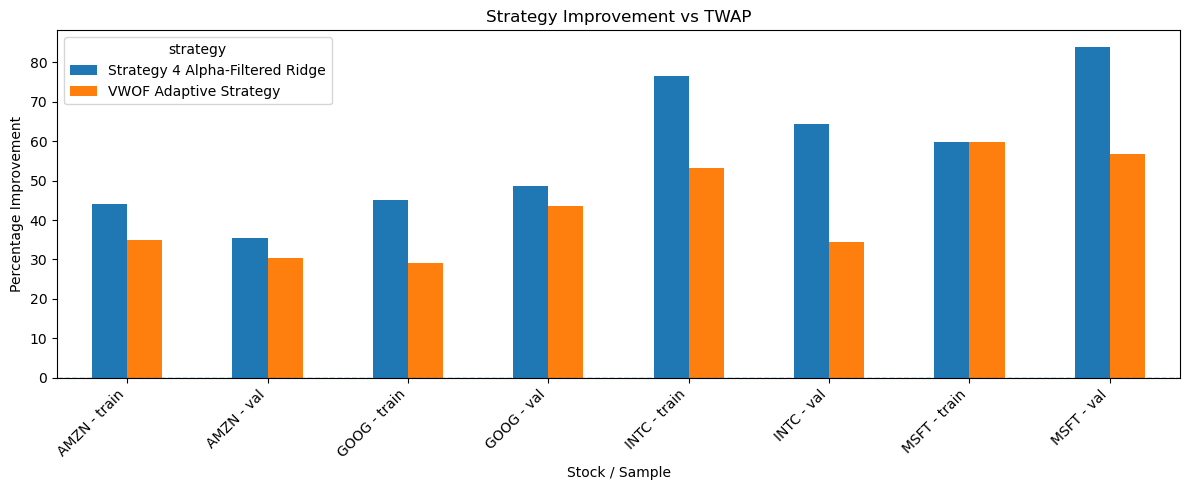

,sample,stock,n_minutes,buy_threshold_hit_rate,sell_threshold_hit_rate,avg_buy_vwof,avg_sell_vwof,avg_buy_spread,avg_sell_spread
0,train,AMZN,189,0.978836,0.984127,0.161859,-0.175149,0.129577,0.131799
1,train,GOOG,189,0.968254,0.962963,0.209471,-0.220102,0.289259,0.287989
2,train,INTC,189,1.000000,1.000000,0.347237,-0.366208,0.010212,0.010317
3,train,MSFT,189,0.994709,0.994709,0.402600,-0.405197,0.010106,0.010265
4,val,AMZN,81,0.987654,0.962963,0.216296,-0.213738,0.103580,0.111975
5,val,GOOG,81,0.925926,0.888889,0.189944,-0.228456,0.212840,0.224074
6,val,INTC,81,1.000000,0.987654,0.336353,-0.324945,0.010247,0.010370
7,val,MSFT,81,1.000000,1.000000,0.408135,-0.397990,0.010247,0.010123


In [7]:
# Compare Strategy 4 + VWOF Strategy vs TWAP

# ------------------------------------------------------------
# 1. Add sample label to TWAP
# ------------------------------------------------------------
minute_sample_map = (
    strategy_df[["stock", "minute", "sample"]]
    .drop_duplicates()
)

twap_trades_with_sample = twap_trades.merge(
    minute_sample_map,
    on=["stock", "minute"],
    how="inner"
)

# ------------------------------------------------------------
# 2. Evaluation function using instructor's metric
# ------------------------------------------------------------
def evaluate_by_stock_and_sample(algo_trades, twap_trades_with_sample, strategy_name):
    merged = algo_trades.merge(
        twap_trades_with_sample,
        on=["stock", "minute", "sample"],
        how="inner"
    )

    rows = []

    for sample in sorted(merged["sample"].dropna().unique()):
        sample_df = merged[merged["sample"] == sample].copy()

        for stock, g in sample_df.groupby("stock"):
            total_algo_buy = g["algo_buy_price"].sum()
            total_algo_sell = g["algo_sell_price"].sum()

            total_twap_buy = g["twap_buy_price"].sum()
            total_twap_sell = g["twap_sell_price"].sum()

            algo_cost = total_algo_buy - total_algo_sell
            twap_cost = total_twap_buy - total_twap_sell

            pct_improvement = np.nan

            if twap_cost != 0:
                pct_improvement = 100 - 100 * algo_cost / twap_cost

            rows.append({
                "strategy": strategy_name,
                "sample": sample,
                "stock": stock,
                "n_minutes": len(g),
                "TOTAL_ALGO_BUY": total_algo_buy,
                "TOTAL_ALGO_SELL": total_algo_sell,
                "TOTAL_TWAP_BUY": total_twap_buy,
                "TOTAL_TWAP_SELL": total_twap_sell,
                "ALGO_COST": algo_cost,
                "TWAP_COST": twap_cost,
                "PCT_IMPROVEMENT": pct_improvement,
            })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 3. Evaluate Strategy 4
#    This assumes strategy4_trades was created earlier.
# ------------------------------------------------------------
strategy4_eval = evaluate_by_stock_and_sample(
    algo_trades=strategy4_trades,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="Strategy 4 Alpha-Filtered Ridge"
)

# ------------------------------------------------------------
# 4. Evaluate VWOF strategy
# ------------------------------------------------------------
vwof_eval = evaluate_by_stock_and_sample(
    algo_trades=vwof_trades,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="VWOF Adaptive Strategy"
)

# ------------------------------------------------------------
# 5. TWAP sanity check
# ------------------------------------------------------------
twap_as_algo = twap_trades_with_sample.rename(columns={
    "twap_time": "algo_buy_time",
    "twap_buy_price": "algo_buy_price",
    "twap_sell_price": "algo_sell_price",
}).copy()

twap_as_algo["algo_sell_time"] = twap_as_algo["algo_buy_time"]

twap_eval = evaluate_by_stock_and_sample(
    algo_trades=twap_as_algo,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="TWAP"
)

# ------------------------------------------------------------
# 6. Display combined result table
# ------------------------------------------------------------
combined_eval = pd.concat(
    [twap_eval, strategy4_eval, vwof_eval],
    ignore_index=True
)

display(combined_eval.sort_values(["sample", "stock", "strategy"]))

# ------------------------------------------------------------
# 7. Plot both strategies together
# ------------------------------------------------------------
plot_eval = combined_eval[
    combined_eval["strategy"] != "TWAP"
].copy()

plot_eval["stock_sample"] = (
    plot_eval["stock"].astype(str)
    + " - "
    + plot_eval["sample"].astype(str)
)

plot_df = plot_eval.pivot_table(
    index="stock_sample",
    columns="strategy",
    values="PCT_IMPROVEMENT",
    aggfunc="first"
)

ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Strategy Improvement vs TWAP")
ax.set_ylabel("Percentage Improvement")
ax.set_xlabel("Stock / Sample")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Trigger diagnostics
# ------------------------------------------------------------
vwof_trigger_diagnostics = (
    vwof_trades
    .groupby(["sample", "stock"])
    .agg(
        n_minutes=("minute", "count"),
        buy_threshold_hit_rate=("buy_trigger", lambda x: (x == "threshold_hit").mean()),
        sell_threshold_hit_rate=("sell_trigger", lambda x: (x == "threshold_hit").mean()),
        avg_buy_vwof=("buy_vwof", "mean"),
        avg_sell_vwof=("sell_vwof", "mean"),
        avg_buy_spread=("buy_spread", "mean"),
        avg_sell_spread=("sell_spread", "mean"),
    )
    .reset_index()
)

display(vwof_trigger_diagnostics)

In [8]:
# ============================================================
# Print Strategy 4 selected alphas with test statistics
# ============================================================

# ------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------
if "selected_features" not in globals():
    raise NameError("selected_features not found. Run the alpha validation cell first.")

if "alpha_validation_summary" not in globals():
    raise NameError("alpha_validation_summary not found. Run the alpha validation cell first.")

# ------------------------------------------------------------
# 2. Build selected alpha statistics table
# ------------------------------------------------------------
selected_alpha_rows = []

for stock in STOCKS:
    for side in ["buy", "sell"]:
        used_alphas = selected_features[stock][side]

        for alpha in used_alphas:
            row = alpha_validation_summary[
                (alpha_validation_summary["stock"] == stock)
                & (alpha_validation_summary["side"] == side)
                & (alpha_validation_summary["alpha"] == alpha)
            ].copy()

            if len(row) == 0:
                selected_alpha_rows.append({
                    "stock": stock,
                    "side": side,
                    "alpha": alpha,
                    "target": "buy_regret" if side == "buy" else "sell_regret",
                    "n": np.nan,
                    "pearson": np.nan,
                    "spearman": np.nan,
                    "slope": np.nan,
                    "t_slope": np.nan,
                    "p_slope": np.nan,
                    "bucket_spread_top_minus_bottom": np.nan,
                    "abs_t_slope": np.nan,
                    "abs_spearman": np.nan,
                    "selection_note": "selected but stats not found",
                })
            else:
                r = row.iloc[0]

                selected_alpha_rows.append({
                    "stock": stock,
                    "side": side,
                    "alpha": alpha,
                    "target": r["target"],
                    "n": r["n"],
                    "pearson": r["pearson"],
                    "spearman": r["spearman"],
                    "slope": r["slope"],
                    "t_slope": r["t_slope"],
                    "p_slope": r["p_slope"],
                    "bucket_spread_top_minus_bottom": r["bucket_spread_top_minus_bottom"],
                    "abs_t_slope": r["abs_t_slope"],
                    "abs_spearman": r["abs_spearman"],
                    "selection_note": (
                        "strong_alpha"
                        if (
                            (pd.notna(r["p_slope"]) and r["p_slope"] <= P_VALUE_CUTOFF)
                            and (pd.notna(r["abs_t_slope"]) and r["abs_t_slope"] >= T_STAT_CUTOFF)
                            and (pd.notna(r["abs_spearman"]) and r["abs_spearman"] >= SPEARMAN_CUTOFF)
                        )
                        else "fallback_top_t_stat"
                    ),
                })

selected_alpha_stats = pd.DataFrame(selected_alpha_rows)

# ------------------------------------------------------------
# 3. Round for display
# ------------------------------------------------------------
display_cols = [
    "stock",
    "side",
    "alpha",
    "target",
    "n",
    "pearson",
    "spearman",
    "slope",
    "t_slope",
    "p_slope",
    "bucket_spread_top_minus_bottom",
    "selection_note",
]

selected_alpha_stats_display = selected_alpha_stats[display_cols].copy()

round_cols = [
    "pearson",
    "spearman",
    "slope",
    "t_slope",
    "p_slope",
    "bucket_spread_top_minus_bottom",
]

for col in round_cols:
    selected_alpha_stats_display[col] = selected_alpha_stats_display[col].round(6)

# ------------------------------------------------------------
# 4. Display full selected alpha table
# ------------------------------------------------------------
selected_alpha_stats_display = selected_alpha_stats_display.sort_values(
    ["stock", "side", "selection_note", "t_slope"],
    ascending=[True, True, True, False]
)

display(selected_alpha_stats_display)

# ------------------------------------------------------------
# 5. Print compact summary by stock-side
# ------------------------------------------------------------
for stock in STOCKS:
    print("=" * 100)
    print(f"{stock}")

    for side in ["buy", "sell"]:
        tmp = selected_alpha_stats_display[
            (selected_alpha_stats_display["stock"] == stock)
            & (selected_alpha_stats_display["side"] == side)
        ].copy()

        print("-" * 100)
        print(f"{side.upper()} model selected alphas: {len(tmp)}")
        display(tmp[[
            "alpha",
            "t_slope",
            "p_slope",
            "spearman",
            "slope",
            "bucket_spread_top_minus_bottom",
            "selection_note",
        ]])

,stock,side,alpha,target,n,pearson,spearman,slope,t_slope,p_slope,bucket_spread_top_minus_bottom,selection_note
1,AMZN,buy,spread,buy_regret,132420,0.212231,0.193911,0.323341,79.029772,0.000000,0.076390,strong_alpha
14,AMZN,buy,n_events_in_min,buy_regret,132420,0.144257,0.155455,0.000046,53.048840,0.000000,0.088181,strong_alpha
8,AMZN,buy,spread_chg1,buy_regret,132420,0.032831,0.029017,0.166889,11.953301,0.000000,0.018557,strong_alpha
2,AMZN,buy,bsz1,buy_regret,132420,0.016043,-0.012945,0.000001,5.838863,0.000000,0.004434,strong_alpha
6,AMZN,buy,total_bid_size_5,buy_regret,132420,0.007313,-0.029060,0.000000,2.661123,0.007789,-0.009264,strong_alpha
...,...,...,...,...,...,...,...,...,...,...,...,...
117,MSFT,sell,depth_value_1,sell_regret,345419,-0.135959,-0.025496,-0.000000,-80.655152,0.000000,-0.013125,strong_alpha
116,MSFT,sell,asz1,sell_regret,345419,-0.173985,-0.153230,-0.000000,-103.838357,0.000000,-0.013299,strong_alpha
129,MSFT,sell,sec_in_min,sell_regret,345419,-0.245891,-0.230033,-0.000206,-149.093075,0.000000,-0.010179,strong_alpha
132,MSFT,sell,event_frac_in_min,sell_regret,345419,-0.278259,-0.276803,-0.014147,-170.263133,0.000000,-0.013569,strong_alpha


AMZN
----------------------------------------------------------------------------------------------------
BUY model selected alphas: 16


,alpha,t_slope,p_slope,spearman,slope,bucket_spread_top_minus_bottom,selection_note
1,spread,79.029772,0.000000,0.193911,0.323341,0.076390,strong_alpha
14,n_events_in_min,53.048840,0.000000,0.155455,0.000046,0.088181,strong_alpha
8,spread_chg1,11.953301,0.000000,0.029017,0.166889,0.018557,strong_alpha
2,bsz1,5.838863,0.000000,-0.012945,0.000001,0.004434,strong_alpha
6,total_bid_size_5,2.661123,0.007789,-0.029060,0.000000,-0.009264,strong_alpha
11,total_ask_size_5_chg1,2.208294,0.027226,0.014154,0.000006,0.003008,strong_alpha
10,ask_liq_1_chg1,2.148615,0.031667,0.018968,0.000000,0.016610,strong_alpha
9,imbalance_1_chg1,-2.311972,0.020781,-0.016063,-0.002579,-0.004853,strong_alpha
3,asz1,-2.977759,0.002904,0.052107,-0.000005,0.023580,strong_alpha
7,imbalance_5,-9.478448,0.000000,-0.033946,-0.006919,-0.005595,strong_alpha


----------------------------------------------------------------------------------------------------
SELL model selected alphas: 12


,alpha,t_slope,p_slope,spearman,slope,bucket_spread_top_minus_bottom,selection_note
26,n_events_in_min,104.072845,0.0,0.156542,0.000097,0.055669,strong_alpha
17,spread,67.327061,0.0,0.218031,0.305200,0.066809,strong_alpha
18,asz1,23.422203,0.0,-0.045658,0.000041,0.002866,strong_alpha
23,spread_chg1,17.918254,0.0,0.038850,0.275277,0.017700,strong_alpha
16,bid1,8.638013,0.0,-0.045999,0.003686,0.019706,strong_alpha
21,micro_minus_mid,7.250161,0.0,0.041162,0.046263,0.008031,strong_alpha
20,imbalance_1,6.624360,0.0,0.031414,0.003382,0.005262,strong_alpha
19,depth_value_1,5.720459,0.0,-0.012623,0.000000,0.018459,strong_alpha
22,imbalance_5,-35.924352,0.0,-0.059076,-0.028745,-0.044957,strong_alpha
25,event_idx_in_min,-54.932774,0.0,-0.186081,-0.000055,-0.065470,strong_alpha


...

,alpha,t_slope,p_slope,spearman,slope,bucket_spread_top_minus_bottom,selection_note
92,n_events_in_min,219.933148,0.0,0.374834,0.000002,0.021748,strong_alpha
82,imbalance_5,211.979425,0.0,0.247494,0.030020,0.016312,strong_alpha
80,micro_minus_mid,199.339091,0.0,0.315269,1.811707,0.018979,strong_alpha
76,spread,196.088895,0.0,0.320514,1.098906,0.013715,strong_alpha
79,imbalance_1,164.809890,0.0,0.299696,0.009904,0.015623,strong_alpha
75,bid1,156.002425,0.0,0.191612,0.028521,0.014191,strong_alpha
91,event_idx_in_min,70.764304,0.0,0.062636,0.000001,0.008539,strong_alpha
88,bid_liq_1_chg1,14.480721,0.0,0.018887,0.000000,0.001494,strong_alpha
84,spread_chg1,13.863342,0.0,0.042566,0.241522,0.007324,strong_alpha
89,total_bid_size_5_chg1,13.306948,0.0,0.019309,0.000000,0.001303,strong_alpha


MSFT
----------------------------------------------------------------------------------------------------
BUY model selected alphas: 19


,alpha,t_slope,p_slope,spearman,slope,bucket_spread_top_minus_bottom,selection_note
111,n_events_in_min,333.338671,0.0,0.417016,0.000005,0.025264,strong_alpha
95,spread,159.325945,0.0,0.262732,0.858346,0.007438,strong_alpha
94,bid1,71.755341,0.0,0.145763,0.010961,0.009748,strong_alpha
97,asz1,42.783493,0.0,0.112368,0.000000,0.004578,strong_alpha
103,spread_chg1,17.002914,0.0,0.039405,0.252210,0.005915,strong_alpha
107,ask_liq_1_chg1,16.099966,0.0,0.021609,0.000000,0.001064,strong_alpha
108,total_ask_size_5_chg1,15.653506,0.0,0.021276,0.000000,0.001041,strong_alpha
102,mid_chg1,12.183587,0.0,0.030358,0.318362,0.005359,strong_alpha
105,imbalance_5_chg1,-12.075162,0.0,-0.021643,-0.015701,-0.001015,strong_alpha
106,micro_minus_mid_chg1,-13.265587,0.0,-0.019672,-0.352370,-0.000944,strong_alpha


----------------------------------------------------------------------------------------------------
SELL model selected alphas: 20


,alpha,t_slope,p_slope,spearman,slope,bucket_spread_top_minus_bottom,selection_note
114,spread,145.580620,0.0,0.273570,0.810612,0.009109,strong_alpha
131,n_events_in_min,145.557185,0.0,0.267969,0.000003,0.010840,strong_alpha
113,bid1,107.273846,0.0,0.116008,0.016690,0.012781,strong_alpha
119,micro_minus_mid,96.898638,0.0,0.207187,0.913104,0.009225,strong_alpha
118,imbalance_1,96.142859,0.0,0.211385,0.005769,0.008662,strong_alpha
127,bid_liq_1_chg1,16.743228,0.0,0.026649,0.000000,0.001185,strong_alpha
128,total_bid_size_5_chg1,16.352406,0.0,0.028273,0.000000,0.001219,strong_alpha
123,spread_chg1,15.954561,0.0,0.043618,0.243226,0.007839,strong_alpha
124,imbalance_1_chg1,13.368900,0.0,0.024253,0.002256,0.001036,strong_alpha
125,imbalance_5_chg1,12.265549,0.0,0.026558,0.016390,0.001007,strong_alpha


In [9]:
# ============================================================
# Cell 8: K-Means Regime Classification Using Order-Event Environment Features
# These regime features avoid direct overlap with Strategy 4 alpha features.
# They use event-type/order-flow mechanics rather than price, spread, depth,
# imbalance, microprice, or within-minute alpha timing variables.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Build non-overlapping environment features for K-Means
# ------------------------------------------------------------
def add_order_event_environment_features(df, window=50):
    df = df.copy()
    df = df.sort_values(["stock", "ts"]).reset_index(drop=True)

    new_order = df["NewLimitOrder_1=Yes_0=No"].astype(float)
    partial_cancel = df["PartialCancel_1=Yes_0=No"].astype(float)
    full_delete = df["FullDelete_1=Yes_0=No"].astype(float)
    visible_exec = df["VisibleExecution_1=Yes_0=No"].astype(float)
    hidden_exec = df["HiddenExecution_1=Yes_0=No"].astype(float)
    direction = df["Direction_1=Buy_-1=Sell"].astype(float)
    size = df["Size"].astype(float)

    df["event_new_order"] = new_order
    df["event_cancel"] = ((partial_cancel == 1) | (full_delete == 1)).astype(float)
    df["event_full_delete"] = full_delete
    df["event_execution"] = ((visible_exec == 1) | (hidden_exec == 1)).astype(float)
    df["event_hidden_execution"] = hidden_exec
    df["event_buy_direction"] = (direction > 0).astype(float)
    df["event_sell_direction"] = (direction < 0).astype(float)
    df["event_abs_size"] = size.abs()
    df["event_signed_size"] = direction * size.abs()

    rolling_base_cols = [
        "event_new_order",
        "event_cancel",
        "event_full_delete",
        "event_execution",
        "event_hidden_execution",
        "event_buy_direction",
        "event_sell_direction",
        "event_abs_size",
        "event_signed_size",
    ]

    for col in rolling_base_cols:
        df[f"{col}_roll50_mean"] = (
            df.groupby("stock")[col]
              .transform(lambda s: s.rolling(window, min_periods=5).mean())
        )

    df["event_abs_size_roll50_std"] = (
        df.groupby("stock")["event_abs_size"]
          .transform(lambda s: s.rolling(window, min_periods=5).std())
    )

    # Ratio features use only event mechanics, not orderbook price/depth state.
    eps = 1e-6
    df["new_to_cancel_ratio_50"] = (
        df["event_new_order_roll50_mean"]
        / (df["event_cancel_roll50_mean"] + eps)
    )
    df["execution_to_new_ratio_50"] = (
        df["event_execution_roll50_mean"]
        / (df["event_new_order_roll50_mean"] + eps)
    )
    df["abs_signed_size_pressure_50"] = df["event_signed_size_roll50_mean"].abs()

    event_regime_features = [
        "event_new_order_roll50_mean",
        "event_cancel_roll50_mean",
        "event_full_delete_roll50_mean",
        "event_execution_roll50_mean",
        "event_hidden_execution_roll50_mean",
        "event_buy_direction_roll50_mean",
        "event_sell_direction_roll50_mean",
        "event_abs_size_roll50_mean",
        "event_abs_size_roll50_std",
        "abs_signed_size_pressure_50",
        "new_to_cancel_ratio_50",
        "execution_to_new_ratio_50",
    ]

    df[event_regime_features] = (
        df[event_regime_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    return df, event_regime_features

strategy_df, regime_features = add_order_event_environment_features(
    strategy_df,
    window=50,
)

print("K-Means event-environment regime features:")
print(regime_features)

# ------------------------------------------------------------
# 2. Fit stock-specific K-Means models on TRAIN only
# ------------------------------------------------------------
N_REGIMES = 4
regime_models = {}

strategy_df = strategy_df.copy()
strategy_df["regime"] = np.nan

for stock in STOCKS:
    stock_train = strategy_df[
        (strategy_df["stock"] == stock)
        & (strategy_df["sample"] == "train")
    ].copy()

    X_train_regime = (
        stock_train[regime_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    kmeans_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(
            n_clusters=N_REGIMES,
            random_state=42,
            n_init=20
        ))
    ])

    kmeans_pipe.fit(X_train_regime)
    regime_models[stock] = kmeans_pipe

    stock_mask = strategy_df["stock"] == stock

    X_all_regime = (
        strategy_df.loc[stock_mask, regime_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    strategy_df.loc[stock_mask, "regime"] = kmeans_pipe.predict(X_all_regime)

strategy_df["regime"] = strategy_df["regime"].astype(int)

# Refresh train/val after adding regime
train_df = strategy_df[strategy_df["sample"] == "train"].copy()
val_df = strategy_df[strategy_df["sample"] == "val"].copy()

# ------------------------------------------------------------
# 3. Regime diagnostics
# ------------------------------------------------------------
regime_counts = (
    strategy_df
    .groupby(["sample", "stock", "regime"])
    .size()
    .reset_index(name="n_rows")
)

display(regime_counts)

regime_summary = (
    strategy_df
    .groupby(["stock", "regime"])[regime_features]
    .mean()
    .reset_index()
)

display(regime_summary)

print("Finished event-environment K-Means regime classification.")

K-Means event-environment regime features:
['event_new_order_roll50_mean', 'event_cancel_roll50_mean', 'event_full_delete_roll50_mean', 'event_execution_roll50_mean', 'event_hidden_execution_roll50_mean', 'event_buy_direction_roll50_mean', 'event_sell_direction_roll50_mean', 'event_abs_size_roll50_mean', 'event_abs_size_roll50_std', 'abs_signed_size_pressure_50', 'new_to_cancel_ratio_50', 'execution_to_new_ratio_50']


,sample,stock,regime,n_rows
0,train,AMZN,0,60469
1,train,AMZN,1,57097
2,train,AMZN,2,200
3,train,AMZN,3,14654
4,train,GOOG,0,54102
5,train,GOOG,1,11882
6,train,GOOG,2,8957
7,train,GOOG,3,3
8,train,INTC,0,163106
9,train,INTC,1,120143


,stock,regime,event_new_order_roll50_mean,event_cancel_roll50_mean,event_full_delete_roll50_mean,event_execution_roll50_mean,event_hidden_execution_roll50_mean,event_buy_direction_roll50_mean,event_sell_direction_roll50_mean,event_abs_size_roll50_mean,event_abs_size_roll50_std,abs_signed_size_pressure_50,new_to_cancel_ratio_50,execution_to_new_ratio_50
0,AMZN,0,0.503220,0.475317,0.470235,0.021463,0.004157,0.604367,0.395633,90.633632,67.592027,29.889187,1.074424,0.044544
1,AMZN,1,0.488240,0.491014,0.486408,0.020746,0.004263,0.355687,0.644313,89.623510,64.070373,29.004594,1.007973,0.044456
2,AMZN,2,0.463700,0.445800,0.432100,0.090500,0.025100,0.462800,0.537200,723.050600,4504.787881,624.943000,1.094169,0.202127
3,AMZN,3,0.457370,0.363327,0.358573,0.179084,0.043737,0.477761,0.522020,92.360515,78.092428,29.891108,1531.288399,0.426334
4,GOOG,0,0.496568,0.470632,0.470557,0.032800,0.009356,0.443397,0.556603,55.272674,50.155387,19.008446,1.070541,0.069332
5,GOOG,1,0.432117,0.353917,0.353662,0.213709,0.088821,0.488790,0.510954,62.995320,65.379818,22.106207,1569.086234,0.532790
6,GOOG,2,0.497946,0.473717,0.473482,0.028337,0.009596,0.779505,0.220495,102.946921,76.819657,74.748920,1.061958,0.061160
7,GOOG,3,0.000000,0.000000,0.000000,1.000000,0.612698,1.000000,0.000000,60.196825,124.903914,60.196825,0.000000,1000000.000000
8,INTC,0,0.492647,0.491667,0.478602,0.015686,0.001896,0.360300,0.639700,427.105174,451.539669,175.542496,1.053010,0.036202
9,INTC,1,0.504536,0.479120,0.469968,0.016343,0.001868,0.783049,0.216951,464.667383,426.189727,291.983612,1.098645,0.036781


Finished event-environment K-Means regime classification.


In [10]:
# ============================================================
# Cell 9: Regime-Specific Ridge Regression + Execution
# Use features NOT used in K-Means for regression
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Helper: choose regression features
#
# Regression features = selected alpha features - regime features.
# If too few remain, fallback to selected alpha features.
# ------------------------------------------------------------
MIN_REGRESSION_FEATURES = 3
MIN_REGIME_TRAIN_ROWS = 500

def get_regime_regression_features(stock, side):
    selected = selected_features[stock][side]

    # Remove features already used for K-Means
    reg_features = [f for f in selected if f not in regime_features]

    # If too few features remain, fallback to selected alpha features
    if len(reg_features) < MIN_REGRESSION_FEATURES:
        reg_features = selected.copy()

    return reg_features

# ------------------------------------------------------------
# 2. Fit fallback stock-level models
#
# These are used only if a regime has too few observations.
# ------------------------------------------------------------
regime_fallback_models = {}

for stock in STOCKS:
    regime_fallback_models[stock] = {}

    for side, target_col in [("buy", "buy_regret"), ("sell", "sell_regret")]:
        stock_train = train_df[train_df["stock"] == stock].copy()
        features = get_regime_regression_features(stock, side)

        X = (
            stock_train[features]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        y = stock_train[target_col]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=10.0))
        ])

        model.fit(X, y)

        regime_fallback_models[stock][side] = {
            "model": model,
            "features": features,
        }

# ------------------------------------------------------------
# 3. Fit regime-specific Ridge models
# ------------------------------------------------------------
regime_ridge_models = {}
regime_ridge_diagnostics = []

for stock in STOCKS:
    regime_ridge_models[stock] = {}

    for regime in sorted(train_df.loc[train_df["stock"] == stock, "regime"].unique()):
        regime = int(regime)
        regime_ridge_models[stock][regime] = {}

        stock_regime_train = train_df[
            (train_df["stock"] == stock)
            & (train_df["regime"] == regime)
        ].copy()

        stock_regime_val = val_df[
            (val_df["stock"] == stock)
            & (val_df["regime"] == regime)
        ].copy()

        for side, target_col in [("buy", "buy_regret"), ("sell", "sell_regret")]:
            features = get_regime_regression_features(stock, side)

            # If regime has too few rows, use fallback model
            if len(stock_regime_train) < MIN_REGIME_TRAIN_ROWS:
                regime_ridge_models[stock][regime][side] = {
                    "model": regime_fallback_models[stock][side]["model"],
                    "features": regime_fallback_models[stock][side]["features"],
                    "is_fallback": True,
                }

                regime_ridge_diagnostics.append({
                    "stock": stock,
                    "regime": regime,
                    "side": side,
                    "n_train": len(stock_regime_train),
                    "n_val": len(stock_regime_val),
                    "n_features": len(features),
                    "is_fallback": True,
                    "train_rmse": np.nan,
                    "val_rmse": np.nan,
                    "train_r2": np.nan,
                    "val_r2": np.nan,
                })

                continue

            X_train = (
                stock_regime_train[features]
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0)
            )
            y_train = stock_regime_train[target_col]

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("ridge", Ridge(alpha=10.0))
            ])

            model.fit(X_train, y_train)

            regime_ridge_models[stock][regime][side] = {
                "model": model,
                "features": features,
                "is_fallback": False,
            }

            train_pred = model.predict(X_train)

            if len(stock_regime_val) > 0:
                X_val = (
                    stock_regime_val[features]
                    .replace([np.inf, -np.inf], np.nan)
                    .fillna(0)
                )
                y_val = stock_regime_val[target_col]
                val_pred = model.predict(X_val)

                val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
                val_r2 = r2_score(y_val, val_pred)
            else:
                val_rmse = np.nan
                val_r2 = np.nan

            regime_ridge_diagnostics.append({
                "stock": stock,
                "regime": regime,
                "side": side,
                "n_train": len(stock_regime_train),
                "n_val": len(stock_regime_val),
                "n_features": len(features),
                "features": features,
                "is_fallback": False,
                "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
                "val_rmse": val_rmse,
                "train_r2": r2_score(y_train, train_pred),
                "val_r2": val_r2,
            })

regime_ridge_diagnostics_df = pd.DataFrame(regime_ridge_diagnostics)
display(regime_ridge_diagnostics_df)

# ------------------------------------------------------------
# 4. Add regime-specific predictions to strategy_df
# ------------------------------------------------------------
def add_regime_predictions(df, regime_ridge_models):
    df = df.copy()
    df["regime_pred_buy_regret"] = np.nan
    df["regime_pred_sell_regret"] = np.nan

    for stock in STOCKS:
        for regime in sorted(df.loc[df["stock"] == stock, "regime"].unique()):
            regime = int(regime)

            mask = (
                (df["stock"] == stock)
                & (df["regime"] == regime)
            )

            if mask.sum() == 0:
                continue

            for side, pred_col in [
                ("buy", "regime_pred_buy_regret"),
                ("sell", "regime_pred_sell_regret"),
            ]:
                model_info = regime_ridge_models[stock][regime][side]
                model = model_info["model"]
                features = model_info["features"]

                X = (
                    df.loc[mask, features]
                    .replace([np.inf, -np.inf], np.nan)
                    .fillna(0)
                )

                df.loc[mask, pred_col] = model.predict(X)

    return df

strategy_df = add_regime_predictions(strategy_df, regime_ridge_models)

train_df = strategy_df[strategy_df["sample"] == "train"].copy()
val_df = strategy_df[strategy_df["sample"] == "val"].copy()

display(strategy_df[[
    "stock",
    "minute",
    "ts",
    "regime",
    "ask1",
    "bid1",
    "buy_regret",
    "sell_regret",
    "regime_pred_buy_regret",
    "regime_pred_sell_regret",
    "sample"
]].head())

# ------------------------------------------------------------
# 5. Regime-specific thresholds
#
# Here we use TRAIN prediction quantiles.
# This avoids over-tuning the regime strategy on validation.
# Lower predicted regret = better execution opportunity.
# ------------------------------------------------------------
REGIME_THRESHOLD_Q = 0.20

regime_thresholds = {}

for stock in STOCKS:
    regime_thresholds[stock] = {}

    for regime in sorted(train_df.loc[train_df["stock"] == stock, "regime"].unique()):
        regime = int(regime)

        tmp = train_df[
            (train_df["stock"] == stock)
            & (train_df["regime"] == regime)
        ].copy()

        if len(tmp) == 0:
            continue

        buy_th = tmp["regime_pred_buy_regret"].quantile(REGIME_THRESHOLD_Q)
        sell_th = tmp["regime_pred_sell_regret"].quantile(REGIME_THRESHOLD_Q)

        regime_thresholds[stock][regime] = {
            "buy_threshold": buy_th,
            "sell_threshold": sell_th,
        }

regime_thresholds_rows = []

for stock in regime_thresholds:
    for regime in regime_thresholds[stock]:
        regime_thresholds_rows.append({
            "stock": stock,
            "regime": regime,
            "buy_threshold": regime_thresholds[stock][regime]["buy_threshold"],
            "sell_threshold": regime_thresholds[stock][regime]["sell_threshold"],
        })

regime_thresholds_df = pd.DataFrame(regime_thresholds_rows)
display(regime_thresholds_df)

# ------------------------------------------------------------
# 6. Execute regime-switching strategy
#
# Within each stock-minute:
# - scan rows from earliest to latest
# - each row already has a K-Means regime
# - use that row's regime-specific threshold
# - if no trigger, fallback to last row
# ------------------------------------------------------------
def execute_regime_switching_strategy(df, regime_thresholds, fallback="last"):
    trades = []

    df = df.sort_values(["stock", "minute", "ts"]).copy()

    for (stock, minute), g in df.groupby(["stock", "minute"], sort=False):
        g = g.sort_values("ts").reset_index(drop=True)

        sample = g["sample"].iloc[0] if "sample" in g.columns else "test"

        buy_row = None
        sell_row = None
        buy_trigger = None
        sell_trigger = None

        # BUY scan
        for _, row in g.iterrows():
            regime = int(row["regime"])

            if stock not in regime_thresholds or regime not in regime_thresholds[stock]:
                continue

            buy_th = regime_thresholds[stock][regime]["buy_threshold"]

            if row["regime_pred_buy_regret"] <= buy_th:
                buy_row = row
                buy_trigger = "regime_threshold_hit"
                break

        # SELL scan
        for _, row in g.iterrows():
            regime = int(row["regime"])

            if stock not in regime_thresholds or regime not in regime_thresholds[stock]:
                continue

            sell_th = regime_thresholds[stock][regime]["sell_threshold"]

            if row["regime_pred_sell_regret"] <= sell_th:
                sell_row = row
                sell_trigger = "regime_threshold_hit"
                break

        if buy_row is None:
            buy_row = g.iloc[-1] if fallback == "last" else g.iloc[0]
            buy_trigger = f"fallback_{fallback}"

        if sell_row is None:
            sell_row = g.iloc[-1] if fallback == "last" else g.iloc[0]
            sell_trigger = f"fallback_{fallback}"

        trades.append({
            "stock": stock,
            "minute": minute,
            "sample": sample,

            "algo_buy_time": buy_row["ts"],
            "algo_sell_time": sell_row["ts"],

            "algo_buy_price": buy_row["ask1"],
            "algo_sell_price": sell_row["bid1"],

            "buy_regime": int(buy_row["regime"]),
            "sell_regime": int(sell_row["regime"]),

            "pred_buy_regret": buy_row["regime_pred_buy_regret"],
            "pred_sell_regret": sell_row["regime_pred_sell_regret"],

            "buy_trigger": buy_trigger,
            "sell_trigger": sell_trigger,
        })

    return pd.DataFrame(trades).sort_values(["stock", "minute"]).reset_index(drop=True)

regime_trades = execute_regime_switching_strategy(
    strategy_df,
    regime_thresholds,
    fallback="last"
)

display(regime_trades.head())
print("Regime-switching trades:", regime_trades.shape)

# ------------------------------------------------------------
# 7. Trigger diagnostics
# ------------------------------------------------------------
regime_trigger_diagnostics = (
    regime_trades
    .groupby(["sample", "stock"])
    .agg(
        n_minutes=("minute", "count"),
        buy_hit_rate=("buy_trigger", lambda x: (x == "regime_threshold_hit").mean()),
        sell_hit_rate=("sell_trigger", lambda x: (x == "regime_threshold_hit").mean()),
        avg_buy_regime=("buy_regime", "mean"),
        avg_sell_regime=("sell_regime", "mean"),
        avg_pred_buy_regret=("pred_buy_regret", "mean"),
        avg_pred_sell_regret=("pred_sell_regret", "mean"),
    )
    .reset_index()
)

display(regime_trigger_diagnostics)

print("Finished regime-switching strategy.")

,stock,regime,side,n_train,n_val,n_features,features,is_fallback,train_rmse,val_rmse,train_r2,val_r2
0,AMZN,0,buy,60469,27371,16,"[bid1, spread, bsz1, asz1, imbalance_1, micro_...",False,0.079178,0.071137,0.232582,-0.003890
1,AMZN,0,sell,60469,27371,12,"[bid1, spread, asz1, depth_value_1, imbalance_...",False,0.086315,0.065630,0.278123,0.324795
2,AMZN,1,buy,57097,11981,16,"[bid1, spread, bsz1, asz1, imbalance_1, micro_...",False,0.079641,0.069817,0.293934,0.153457
3,AMZN,1,sell,57097,11981,12,"[bid1, spread, asz1, depth_value_1, imbalance_...",False,0.081698,0.055739,0.194698,0.052728
4,AMZN,2,buy,200,0,16,NaN,True,NaN,NaN,NaN,NaN
5,AMZN,2,sell,200,0,12,NaN,True,NaN,NaN,NaN,NaN
6,AMZN,3,buy,14654,3566,16,"[bid1, spread, bsz1, asz1, imbalance_1, micro_...",False,0.111546,0.094861,0.245456,-0.003102
7,AMZN,3,sell,14654,3566,12,"[bid1, spread, asz1, depth_value_1, imbalance_...",False,0.121997,0.071007,0.458801,-0.453745
8,GOOG,0,buy,54102,19913,15,"[bid1, spread, bsz1, depth_value_1, imbalance_...",False,0.166501,0.127225,0.355229,-0.075726
9,GOOG,0,sell,54102,19913,13,"[bid1, spread, bsz1, depth_value_1, imbalance_...",False,0.152265,0.106447,0.260674,0.332135


,stock,minute,ts,regime,ask1,bid1,buy_regret,sell_regret,regime_pred_buy_regret,regime_pred_sell_regret,sample
0,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.017,3,223.95,223.18,0.09,1.11,0.439183,0.611509,train
1,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,3,223.95,223.81,0.09,0.48,0.239191,0.189424,train
2,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,3,223.95,223.81,0.09,0.48,0.185638,0.182420,train
3,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,3,223.95,223.81,0.09,0.48,0.185247,0.182131,train
4,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,3,223.95,223.81,0.09,0.48,0.184856,0.181842,train


,stock,regime,buy_threshold,sell_threshold
0,AMZN,0,0.033336,0.039136
1,AMZN,1,0.042209,0.039135
2,AMZN,2,0.092602,0.059916
3,AMZN,3,0.051716,0.037198
4,GOOG,0,0.074974,0.060243
5,GOOG,1,0.036167,0.055450
6,GOOG,2,0.094935,0.119464
7,GOOG,3,0.889896,0.445056
8,INTC,0,0.001650,0.001451
9,INTC,1,-0.000093,0.002040


,stock,minute,sample,algo_buy_time,algo_sell_time,algo_buy_price,algo_sell_price,buy_regime,sell_regime,pred_buy_regret,pred_sell_regret,buy_trigger,sell_trigger
0,AMZN,1900-01-01 09:30:00,train,1900-01-01 09:30:12.376,1900-01-01 09:30:45.512,224.24,224.13,3,3,0.048823,0.002194,regime_threshold_hit,regime_threshold_hit
1,AMZN,1900-01-01 09:31:00,train,1900-01-01 09:31:51.248,1900-01-01 09:31:50.319,223.81,223.50,3,3,0.036253,0.004961,regime_threshold_hit,regime_threshold_hit
2,AMZN,1900-01-01 09:32:00,train,1900-01-01 09:32:37.318,1900-01-01 09:32:14.312,223.99,224.17,3,3,0.022796,-0.036120,regime_threshold_hit,regime_threshold_hit
3,AMZN,1900-01-01 09:33:00,train,1900-01-01 09:33:51.282,1900-01-01 09:33:53.007,223.86,224.00,3,3,0.051092,0.030544,regime_threshold_hit,regime_threshold_hit
4,AMZN,1900-01-01 09:34:00,train,1900-01-01 09:34:46.984,1900-01-01 09:34:46.984,224.55,224.39,1,1,0.041660,0.038582,regime_threshold_hit,regime_threshold_hit


Regime-switching trades: (1080, 13)


,sample,stock,n_minutes,buy_hit_rate,sell_hit_rate,avg_buy_regime,avg_sell_regime,avg_pred_buy_regret,avg_pred_sell_regret
0,train,AMZN,189,0.984127,0.978836,0.767196,1.010582,0.033334,0.028761
1,train,GOOG,189,0.968254,0.989418,0.560847,0.486772,0.058475,0.052877
2,train,INTC,189,0.973545,0.925926,1.164021,1.164021,0.001448,0.001685
3,train,MSFT,189,1.000000,0.936508,1.285714,1.497354,0.002440,0.003128
4,val,AMZN,81,1.000000,0.987654,0.814815,1.098765,0.031652,0.027576
5,val,GOOG,81,0.975309,1.000000,0.617284,0.580247,0.046075,0.046642
6,val,INTC,81,1.000000,0.950617,0.962963,1.395062,0.000962,0.001462
7,val,MSFT,81,1.000000,1.000000,1.456790,1.432099,0.001669,0.001770


Finished regime-switching strategy.


,strategy,sample,stock,n_minutes,TOTAL_ALGO_BUY,TOTAL_ALGO_SELL,TOTAL_TWAP_BUY,TOTAL_TWAP_SELL,ALGO_COST,TWAP_COST,PCT_IMPROVEMENT
24,Event-Regime Ridge,train,AMZN,189,42322.55,42308.01,42329.42,42300.99,14.54,28.43,48.856841
8,Strategy 4 Alpha-Filtered Ridge,train,AMZN,189,42323.09,42307.21,42329.42,42300.99,15.88,28.43,44.143510
16,Strategy 5 VWOF Adaptive,train,AMZN,189,42323.48,42304.96,42329.42,42300.99,18.52,28.43,34.857545
0,TWAP,train,AMZN,189,42329.42,42300.99,42329.42,42300.99,28.43,28.43,0.000000
25,Event-Regime Ridge,train,GOOG,189,108492.54,108455.77,108509.95,108449.91,36.77,60.04,38.757495
9,Strategy 4 Alpha-Filtered Ridge,train,GOOG,189,108489.45,108456.42,108509.95,108449.91,33.03,60.04,44.986676
17,Strategy 5 VWOF Adaptive,train,GOOG,189,108497.84,108455.23,108509.95,108449.91,42.61,60.04,29.030646
1,TWAP,train,GOOG,189,108509.95,108449.91,108509.95,108449.91,60.04,60.04,0.000000
26,Event-Regime Ridge,train,INTC,189,5152.69,5152.25,5153.84,5151.92,0.44,1.92,77.083333
10,Strategy 4 Alpha-Filtered Ridge,train,INTC,189,5152.73,5152.28,5153.84,5151.92,0.45,1.92,76.562500


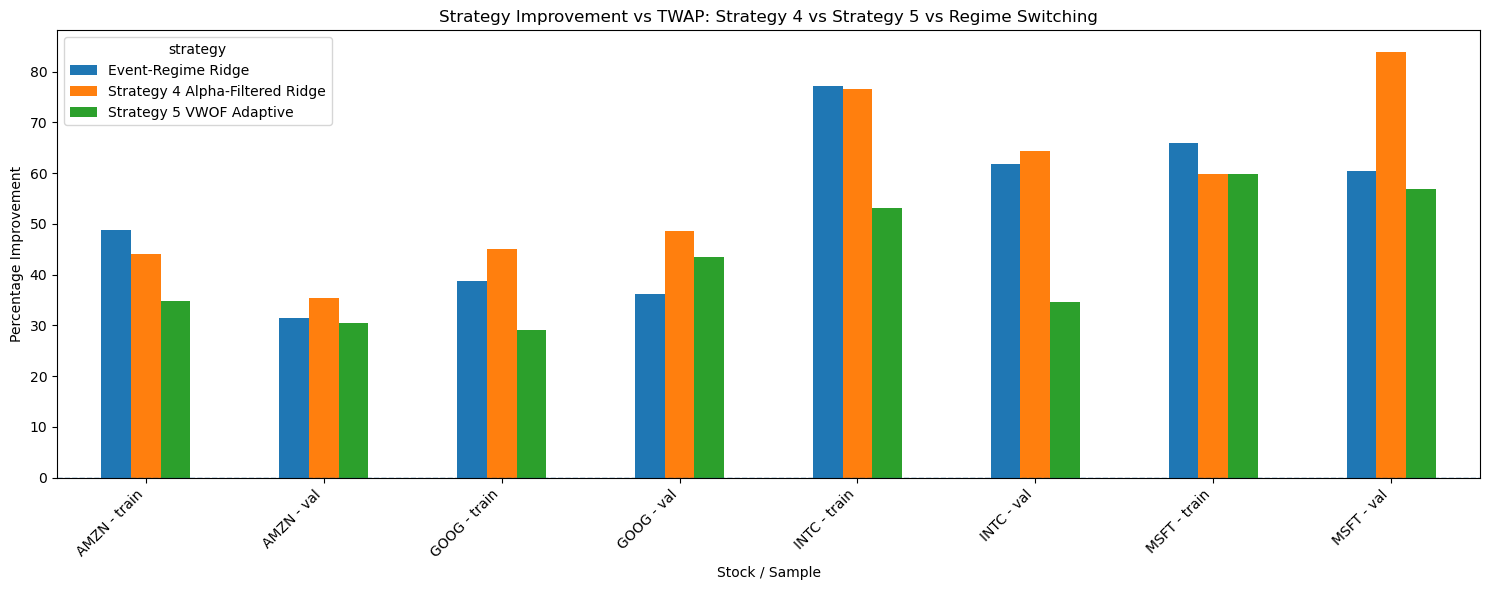

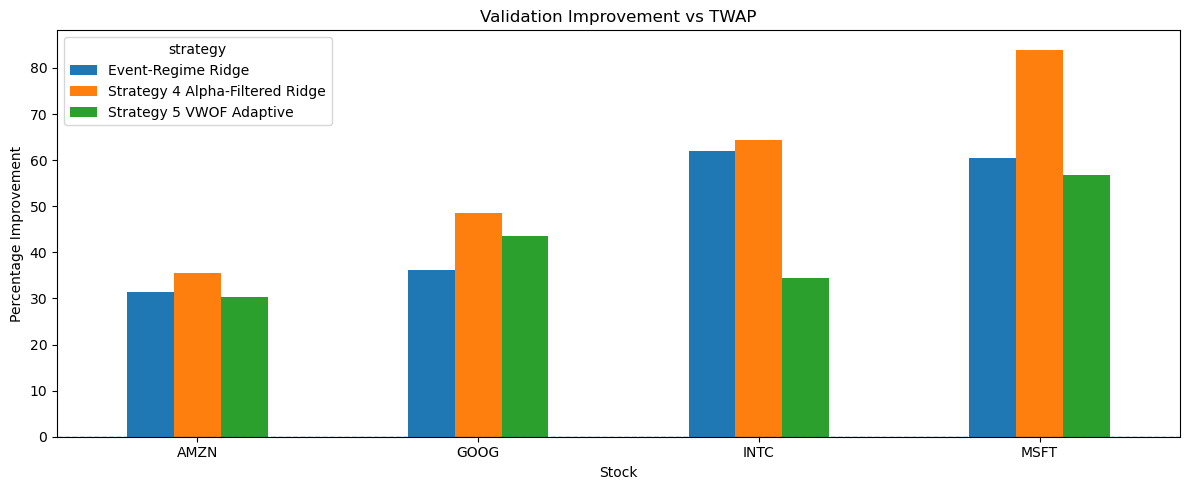

In [11]:
# ============================================================
# Cell 10: Compare Strategy 4, Strategy 5, and Regime Switching
# ============================================================

# ------------------------------------------------------------
# 1. Build TWAP with sample label
# ------------------------------------------------------------
minute_sample_map = (
    strategy_df[["stock", "minute", "sample"]]
    .drop_duplicates()
)

twap_trades_with_sample = twap_trades.merge(
    minute_sample_map,
    on=["stock", "minute"],
    how="inner"
)

# ------------------------------------------------------------
# 2. Evaluation function
#
# Instructor's required metric:
# 100 - 100 * (TOTAL_ALGO_BUY - TOTAL_ALGO_SELL)
#             / (TOTAL_TWAP_BUY - TOTAL_TWAP_SELL)
# ------------------------------------------------------------
def evaluate_by_stock_and_sample(algo_trades, twap_trades_with_sample, strategy_name):
    merged = algo_trades.merge(
        twap_trades_with_sample,
        on=["stock", "minute", "sample"],
        how="inner"
    )

    rows = []

    for sample in sorted(merged["sample"].dropna().unique()):
        sample_df = merged[merged["sample"] == sample].copy()

        for stock, g in sample_df.groupby("stock"):
            total_algo_buy = g["algo_buy_price"].sum()
            total_algo_sell = g["algo_sell_price"].sum()

            total_twap_buy = g["twap_buy_price"].sum()
            total_twap_sell = g["twap_sell_price"].sum()

            algo_cost = total_algo_buy - total_algo_sell
            twap_cost = total_twap_buy - total_twap_sell

            pct_improvement = np.nan
            if twap_cost != 0:
                pct_improvement = 100 - 100 * algo_cost / twap_cost

            rows.append({
                "strategy": strategy_name,
                "sample": sample,
                "stock": stock,
                "n_minutes": len(g),
                "TOTAL_ALGO_BUY": total_algo_buy,
                "TOTAL_ALGO_SELL": total_algo_sell,
                "TOTAL_TWAP_BUY": total_twap_buy,
                "TOTAL_TWAP_SELL": total_twap_sell,
                "ALGO_COST": algo_cost,
                "TWAP_COST": twap_cost,
                "PCT_IMPROVEMENT": pct_improvement,
            })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 3. Evaluate all three strategies
# ------------------------------------------------------------
strategy4_eval = evaluate_by_stock_and_sample(
    algo_trades=strategy4_trades,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="Strategy 4 Alpha-Filtered Ridge"
)

vwof_eval = evaluate_by_stock_and_sample(
    algo_trades=vwof_trades,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="Strategy 5 VWOF Adaptive"
)

regime_eval = evaluate_by_stock_and_sample(
    algo_trades=regime_trades,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="Event-Regime Ridge"
)

# TWAP sanity check
twap_as_algo = twap_trades_with_sample.rename(columns={
    "twap_time": "algo_buy_time",
    "twap_buy_price": "algo_buy_price",
    "twap_sell_price": "algo_sell_price",
}).copy()

twap_as_algo["algo_sell_time"] = twap_as_algo["algo_buy_time"]

twap_eval = evaluate_by_stock_and_sample(
    algo_trades=twap_as_algo,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="TWAP"
)

combined_eval_3strategies = pd.concat(
    [twap_eval, strategy4_eval, vwof_eval, regime_eval],
    ignore_index=True
)

display(
    combined_eval_3strategies
    .sort_values(["sample", "stock", "strategy"])
)

# ------------------------------------------------------------
# 4. Plot all three strategies together
# ------------------------------------------------------------
plot_eval = combined_eval_3strategies[
    combined_eval_3strategies["strategy"] != "TWAP"
].copy()

plot_eval["stock_sample"] = (
    plot_eval["stock"].astype(str)
    + " - "
    + plot_eval["sample"].astype(str)
)

plot_df = plot_eval.pivot_table(
    index="stock_sample",
    columns="strategy",
    values="PCT_IMPROVEMENT",
    aggfunc="first"
)

ax = plot_df.plot(kind="bar", figsize=(15, 6))
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Strategy Improvement vs TWAP: Strategy 4 vs Strategy 5 vs Regime Switching")
ax.set_ylabel("Percentage Improvement")
ax.set_xlabel("Stock / Sample")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Validation-only plot
# ------------------------------------------------------------
plot_val = combined_eval_3strategies[
    (combined_eval_3strategies["strategy"] != "TWAP")
    & (combined_eval_3strategies["sample"] == "val")
].copy()

plot_val_df = plot_val.pivot_table(
    index="stock",
    columns="strategy",
    values="PCT_IMPROVEMENT",
    aggfunc="first"
)

ax = plot_val_df.plot(kind="bar", figsize=(12, 5))
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Validation Improvement vs TWAP")
ax.set_ylabel("Percentage Improvement")
ax.set_xlabel("Stock")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Cell: Hierarchical / Layered Strategy
# Strategy 4 Ridge signal + Strategy 5 VWOF safety filter
# Put this after the K-Means code block
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------
required_cols = [
    "stock", "minute", "ts", "ask1", "bid1",
    "pred_buy_regret", "pred_sell_regret",
    "Direction_1=Buy_-1=Sell", "Size",
    "NewLimitOrder_1=Yes_0=No",
    "PartialCancel_1=Yes_0=No",
    "FullDelete_1=Yes_0=No",
    "VisibleExecution_1=Yes_0=No",
    "HiddenExecution_1=Yes_0=No",
]

missing_cols = [c for c in required_cols if c not in strategy_df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

if "best_thresholds" not in globals():
    raise NameError("best_thresholds not found. Run Strategy 4 threshold tuning first.")

# ------------------------------------------------------------
# 2. Build Strategy 5 style VWOF / MicroMomentum safety signals
#
# Strict no-look-ahead:
# - VWOF is shifted by 1 row
# - MicroMomentum is shifted by 1 row
# - rolling thresholds are shifted by 1 row
# ------------------------------------------------------------
def add_hierarchical_filter_signals(stock_df):
    df = stock_df.copy()
    df = df.sort_values("ts").reset_index(drop=True)

    direction = df["Direction_1=Buy_-1=Sell"].values
    size = df["Size"].values

    is_new = df["NewLimitOrder_1=Yes_0=No"].values

    is_cancel = (
        df["PartialCancel_1=Yes_0=No"].astype(bool)
        | df["FullDelete_1=Yes_0=No"].astype(bool)
    ).values

    is_exec = (
        df["VisibleExecution_1=Yes_0=No"].astype(bool)
        | df["HiddenExecution_1=Yes_0=No"].astype(bool)
    ).values

    flow = np.zeros(len(df))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)

    net_flow_50 = pd.Series(flow, index=df.index).rolling(
        50, min_periods=10
    ).sum()

    total_vol_50 = pd.Series(abs_flow, index=df.index).rolling(
        50, min_periods=10
    ).sum()

    df["H_VWOF_Raw"] = (net_flow_50 / (total_vol_50 + 1e-9)).fillna(0.0)
    df["H_VWOF"] = df["H_VWOF_Raw"].shift(1).fillna(0.0)

    df["H_MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2

    df["H_MicroPrice"] = (
        df["BidPrice_1"] * df["AskSize_1"]
        + df["AskPrice_1"] * df["BidSize_1"]
    ) / (df["BidSize_1"] + df["AskSize_1"] + 1e-9)

    df["H_MicroMomentum"] = (
        df["H_MicroPrice"] - df["H_MidPrice"]
    ).shift(1).fillna(0.0)

    df["H_Spread"] = df["AskPrice_1"] - df["BidPrice_1"]
    df["H_Depth_1"] = df["BidSize_1"] + df["AskSize_1"]

    lookback = 600
    min_obs = 50

    spread_hist = df["H_Spread"].rolling(lookback, min_periods=min_obs)
    vwof_abs_hist = df["H_VWOF"].abs().rolling(lookback, min_periods=min_obs)
    mom_abs_hist = df["H_MicroMomentum"].abs().rolling(lookback, min_periods=min_obs)
    depth_hist = df["H_Depth_1"].rolling(lookback, min_periods=min_obs)

    df["H_Spread_Limit"] = spread_hist.quantile(0.70).shift(1)
    df["H_Spread_Median"] = spread_hist.median().shift(1)
    df["H_VWOF_Guard"] = vwof_abs_hist.quantile(0.65).shift(1).clip(0.08, 0.35)
    df["H_Momentum_Guard"] = mom_abs_hist.quantile(0.60).shift(1)
    df["H_Depth_Median"] = depth_hist.median().shift(1)

    df["H_Spread_Limit"] = df["H_Spread_Limit"].ffill().fillna(df["H_Spread"])
    df["H_Spread_Median"] = df["H_Spread_Median"].ffill().fillna(df["H_Spread"])
    df["H_VWOF_Guard"] = df["H_VWOF_Guard"].ffill().fillna(0.20)
    df["H_Momentum_Guard"] = df["H_Momentum_Guard"].ffill().fillna(0.0)
    df["H_Depth_Median"] = df["H_Depth_Median"].ffill().fillna(df["H_Depth_1"])

    return df


# ------------------------------------------------------------
# 3. Apply safety signals to all stocks
# ------------------------------------------------------------
hierarchical_signal_dfs = []

for stock in STOCKS:
    stock_df = strategy_df[strategy_df["stock"] == stock].copy()
    stock_signal_df = add_hierarchical_filter_signals(stock_df)
    hierarchical_signal_dfs.append(stock_signal_df)

hierarchical_df = pd.concat(hierarchical_signal_dfs, ignore_index=True)
hierarchical_df = hierarchical_df.sort_values(["stock", "minute", "ts"]).reset_index(drop=True)

display(hierarchical_df[[
    "stock", "minute", "ts",
    "pred_buy_regret", "pred_sell_regret",
    "H_VWOF", "H_MicroMomentum", "H_Spread", "H_Spread_Limit"
]].head())

# ------------------------------------------------------------
# 4. Hierarchical execution rule
#
# BUY:
# - Strategy 4 says predicted buy regret is low
# - spread is safe
# - VWOF / MicroMomentum are not strongly against buying
#
# SELL:
# - Strategy 4 says predicted sell regret is low
# - spread is safe
# - VWOF / MicroMomentum are not strongly against selling
# ------------------------------------------------------------
def execute_hierarchical_strategy(df, best_thresholds, fallback="last"):
    trades = []

    df = df.sort_values(["stock", "minute", "ts"]).copy()

    for (stock, minute), g in df.groupby(["stock", "minute"], sort=False):
        g = g.sort_values("ts").reset_index(drop=True)

        sample = g["sample"].iloc[0] if "sample" in g.columns else "test"

        buy_row = None
        sell_row = None
        buy_trigger = None
        sell_trigger = None

        buy_th = best_thresholds[stock]["buy_threshold"]
        sell_th = best_thresholds[stock]["sell_threshold"]

        # ----------------------------
        # BUY scan
        # ----------------------------
        for _, row in g.iterrows():
            elapsed = (row["ts"] - row["minute"]).total_seconds()
            time_progress = min(max(elapsed / 60.0, 0.0), 1.0)

            spread_safe = row["H_Spread"] <= row["H_Spread_Limit"]

            # Strategy 4 main signal
            ridge_buy_signal = row["pred_buy_regret"] <= buy_th

            # Strategy 5 safety filter:
            # For BUY, we do not want strongly negative order-flow pressure.
            vwof_not_against_buy = row["H_VWOF"] >= -row["H_VWOF_Guard"]
            momentum_not_against_buy = row["H_MicroMomentum"] >= -row["H_Momentum_Guard"]

            # If very late in the minute, relax the order-flow filter slightly
            if time_progress > 0.85:
                vwof_not_against_buy = row["H_VWOF"] >= -1.5 * row["H_VWOF_Guard"]
                momentum_not_against_buy = row["H_MicroMomentum"] >= -1.5 * row["H_Momentum_Guard"]

            if ridge_buy_signal and spread_safe and vwof_not_against_buy and momentum_not_against_buy:
                buy_row = row
                buy_trigger = "ridge_signal_passed_vwof_filter"
                break

        # ----------------------------
        # SELL scan
        # ----------------------------
        for _, row in g.iterrows():
            elapsed = (row["ts"] - row["minute"]).total_seconds()
            time_progress = min(max(elapsed / 60.0, 0.0), 1.0)

            spread_safe = row["H_Spread"] <= row["H_Spread_Limit"]

            # Strategy 4 main signal
            ridge_sell_signal = row["pred_sell_regret"] <= sell_th

            # Strategy 5 safety filter:
            # For SELL, we do not want strongly positive order-flow pressure.
            vwof_not_against_sell = row["H_VWOF"] <= row["H_VWOF_Guard"]
            momentum_not_against_sell = row["H_MicroMomentum"] <= row["H_Momentum_Guard"]

            # If very late in the minute, relax the order-flow filter slightly
            if time_progress > 0.85:
                vwof_not_against_sell = row["H_VWOF"] <= 1.5 * row["H_VWOF_Guard"]
                momentum_not_against_sell = row["H_MicroMomentum"] <= 1.5 * row["H_Momentum_Guard"]

            if ridge_sell_signal and spread_safe and vwof_not_against_sell and momentum_not_against_sell:
                sell_row = row
                sell_trigger = "ridge_signal_passed_vwof_filter"
                break

        # ----------------------------
        # Fallback
        # ----------------------------
        if buy_row is None:
            buy_row = g.iloc[-1] if fallback == "last" else g.iloc[0]
            buy_trigger = f"fallback_{fallback}"

        if sell_row is None:
            sell_row = g.iloc[-1] if fallback == "last" else g.iloc[0]
            sell_trigger = f"fallback_{fallback}"

        trades.append({
            "stock": stock,
            "minute": minute,
            "sample": sample,

            "algo_buy_time": buy_row["ts"],
            "algo_sell_time": sell_row["ts"],

            "algo_buy_price": buy_row["ask1"],
            "algo_sell_price": sell_row["bid1"],

            "pred_buy_regret": buy_row["pred_buy_regret"],
            "pred_sell_regret": sell_row["pred_sell_regret"],

            "buy_vwof": buy_row["H_VWOF"],
            "sell_vwof": sell_row["H_VWOF"],

            "buy_micro_momentum": buy_row["H_MicroMomentum"],
            "sell_micro_momentum": sell_row["H_MicroMomentum"],

            "buy_spread": buy_row["H_Spread"],
            "sell_spread": sell_row["H_Spread"],

            "buy_trigger": buy_trigger,
            "sell_trigger": sell_trigger,
        })

    return pd.DataFrame(trades).sort_values(["stock", "minute"]).reset_index(drop=True)


hierarchical_trades = execute_hierarchical_strategy(
    hierarchical_df,
    best_thresholds,
    fallback="last"
)

display(hierarchical_trades.head())
print("Hierarchical strategy trades:", hierarchical_trades.shape)

# ------------------------------------------------------------
# 5. Evaluate hierarchical strategy vs TWAP
# ------------------------------------------------------------
minute_sample_map = (
    strategy_df[["stock", "minute", "sample"]]
    .drop_duplicates()
)

twap_trades_with_sample = twap_trades.merge(
    minute_sample_map,
    on=["stock", "minute"],
    how="inner"
)

def evaluate_by_stock_and_sample(algo_trades, twap_trades_with_sample, strategy_name):
    merged = algo_trades.merge(
        twap_trades_with_sample,
        on=["stock", "minute", "sample"],
        how="inner"
    )

    rows = []

    for sample in sorted(merged["sample"].dropna().unique()):
        sample_df = merged[merged["sample"] == sample].copy()

        for stock, g in sample_df.groupby("stock"):
            total_algo_buy = g["algo_buy_price"].sum()
            total_algo_sell = g["algo_sell_price"].sum()

            total_twap_buy = g["twap_buy_price"].sum()
            total_twap_sell = g["twap_sell_price"].sum()

            algo_cost = total_algo_buy - total_algo_sell
            twap_cost = total_twap_buy - total_twap_sell

            pct_improvement = np.nan
            if twap_cost != 0:
                pct_improvement = 100 - 100 * algo_cost / twap_cost

            rows.append({
                "strategy": strategy_name,
                "sample": sample,
                "stock": stock,
                "n_minutes": len(g),
                "TOTAL_ALGO_BUY": total_algo_buy,
                "TOTAL_ALGO_SELL": total_algo_sell,
                "TOTAL_TWAP_BUY": total_twap_buy,
                "TOTAL_TWAP_SELL": total_twap_sell,
                "ALGO_COST": algo_cost,
                "TWAP_COST": twap_cost,
                "PCT_IMPROVEMENT": pct_improvement,
            })

    return pd.DataFrame(rows)


hierarchical_eval = evaluate_by_stock_and_sample(
    algo_trades=hierarchical_trades,
    twap_trades_with_sample=twap_trades_with_sample,
    strategy_name="Hierarchical Ridge + VWOF Filter"
)

display(hierarchical_eval)

# ------------------------------------------------------------
# 6. Trigger diagnostics
# ------------------------------------------------------------
hierarchical_trigger_diagnostics = (
    hierarchical_trades
    .groupby(["sample", "stock"])
    .agg(
        n_minutes=("minute", "count"),
        buy_hit_rate=("buy_trigger", lambda x: (x == "ridge_signal_passed_vwof_filter").mean()),
        sell_hit_rate=("sell_trigger", lambda x: (x == "ridge_signal_passed_vwof_filter").mean()),
        avg_buy_vwof=("buy_vwof", "mean"),
        avg_sell_vwof=("sell_vwof", "mean"),
        avg_buy_spread=("buy_spread", "mean"),
        avg_sell_spread=("sell_spread", "mean"),
    )
    .reset_index()
)

display(hierarchical_trigger_diagnostics)

,stock,minute,ts,pred_buy_regret,pred_sell_regret,H_VWOF,H_MicroMomentum,H_Spread,H_Spread_Limit
0,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.017,0.386996,0.385997,0.0,0.000000e+00,0.77,0.77
1,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,0.140142,0.123378,0.0,-1.117797e-09,0.14,0.14
2,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,0.141026,0.125611,0.0,-4.570248e-02,0.14,0.14
3,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,0.141028,0.124672,0.0,-4.570248e-02,0.14,0.14
4,AMZN,1900-01-01 09:30:00,1900-01-01 09:30:00.189,0.141097,0.124222,0.0,-4.570248e-02,0.14,0.14


,stock,minute,sample,algo_buy_time,algo_sell_time,algo_buy_price,algo_sell_price,pred_buy_regret,pred_sell_regret,buy_vwof,sell_vwof,buy_micro_momentum,sell_micro_momentum,buy_spread,sell_spread,buy_trigger,sell_trigger
0,AMZN,1900-01-01 09:30:00,train,1900-01-01 09:30:59.726,1900-01-01 09:30:45.512,224.35,224.13,0.138318,-0.000341,0.003707,-0.123487,-0.122500,-1.050000e-01,0.49,0.06,fallback_last,ridge_signal_passed_vwof_filter
1,AMZN,1900-01-01 09:31:00,train,1900-01-01 09:31:51.248,1900-01-01 09:31:52.997,223.81,223.50,0.010827,0.013372,-0.118672,-0.001187,0.151931,1.519307e-01,0.08,0.17,ridge_signal_passed_vwof_filter,ridge_signal_passed_vwof_filter
2,AMZN,1900-01-01 09:32:00,train,1900-01-01 09:32:14.312,1900-01-01 09:32:14.313,224.19,224.17,0.036109,-0.018404,0.122501,0.056177,-0.050000,-5.604477e-10,0.02,0.02,ridge_signal_passed_vwof_filter,ridge_signal_passed_vwof_filter
3,AMZN,1900-01-01 09:33:00,train,1900-01-01 09:33:53.007,1900-01-01 09:33:53.007,224.18,224.00,0.036172,0.007810,0.016987,0.016987,-0.093108,-9.310811e-02,0.18,0.18,ridge_signal_passed_vwof_filter,ridge_signal_passed_vwof_filter
4,AMZN,1900-01-01 09:34:00,train,1900-01-01 09:34:46.985,1900-01-01 09:34:46.985,224.53,224.41,0.033352,0.021086,-0.034056,-0.032528,0.158529,8.212289e-03,0.12,0.13,ridge_signal_passed_vwof_filter,ridge_signal_passed_vwof_filter


Hierarchical strategy trades: (1080, 17)


,strategy,sample,stock,n_minutes,TOTAL_ALGO_BUY,TOTAL_ALGO_SELL,TOTAL_TWAP_BUY,TOTAL_TWAP_SELL,ALGO_COST,TWAP_COST,PCT_IMPROVEMENT
0,Hierarchical Ridge + VWOF Filter,train,AMZN,189,42323.44,42306.35,42329.42,42300.99,17.09,28.43,39.887443
1,Hierarchical Ridge + VWOF Filter,train,GOOG,189,108489.94,108456.10,108509.95,108449.91,33.84,60.04,43.637575
2,Hierarchical Ridge + VWOF Filter,train,INTC,189,5152.72,5152.30,5153.84,5151.92,0.42,1.92,78.125000
3,Hierarchical Ridge + VWOF Filter,train,MSFT,189,5816.79,5816.09,5817.80,5815.86,0.70,1.94,63.917526
4,Hierarchical Ridge + VWOF Filter,val,AMZN,81,18018.60,18012.27,18020.80,18011.65,6.33,9.15,30.819672
5,Hierarchical Ridge + VWOF Filter,val,GOOG,81,46086.25,46075.49,46090.53,46071.01,10.76,19.52,44.877049
6,Hierarchical Ridge + VWOF Filter,val,INTC,81,2179.26,2178.99,2179.58,2178.74,0.27,0.84,67.857143
7,Hierarchical Ridge + VWOF Filter,val,MSFT,81,2466.60,2466.51,2467.03,2466.22,0.09,0.81,88.888889


,sample,stock,n_minutes,buy_hit_rate,sell_hit_rate,avg_buy_vwof,avg_sell_vwof,avg_buy_spread,avg_sell_spread
0,train,AMZN,189,0.952381,0.910053,0.022147,-0.019962,0.094656,0.099418
1,train,GOOG,189,0.640212,0.994709,0.011146,-0.044715,0.233862,0.196190
2,train,INTC,189,0.878307,0.962963,0.198266,-0.206904,0.010106,0.010053
3,train,MSFT,189,0.687831,0.920635,0.192669,-0.108187,0.010106,0.010106
4,val,AMZN,81,1.000000,0.938272,0.000930,-0.022894,0.080494,0.081358
5,val,GOOG,81,0.740741,0.987654,-0.033333,-0.080183,0.181852,0.170864
6,val,INTC,81,1.000000,0.987654,0.188906,-0.172017,0.010123,0.010000
7,val,MSFT,81,0.950617,1.000000,0.258356,-0.192479,0.010000,0.010000


,strategy,sample,stock,n_minutes,TOTAL_ALGO_BUY,TOTAL_ALGO_SELL,TOTAL_TWAP_BUY,TOTAL_TWAP_SELL,ALGO_COST,TWAP_COST,PCT_IMPROVEMENT
16,Event-Regime Ridge,train,AMZN,189,42322.55,42308.01,42329.42,42300.99,14.54,28.43,48.856841
24,Hierarchical Ridge + VWOF Filter,train,AMZN,189,42323.44,42306.35,42329.42,42300.99,17.09,28.43,39.887443
0,Strategy 4 Alpha-Filtered Ridge,train,AMZN,189,42323.09,42307.21,42329.42,42300.99,15.88,28.43,44.143510
8,Strategy 5 VWOF Adaptive,train,AMZN,189,42323.48,42304.96,42329.42,42300.99,18.52,28.43,34.857545
17,Event-Regime Ridge,train,GOOG,189,108492.54,108455.77,108509.95,108449.91,36.77,60.04,38.757495
25,Hierarchical Ridge + VWOF Filter,train,GOOG,189,108489.94,108456.10,108509.95,108449.91,33.84,60.04,43.637575
1,Strategy 4 Alpha-Filtered Ridge,train,GOOG,189,108489.45,108456.42,108509.95,108449.91,33.03,60.04,44.986676
9,Strategy 5 VWOF Adaptive,train,GOOG,189,108497.84,108455.23,108509.95,108449.91,42.61,60.04,29.030646
18,Event-Regime Ridge,train,INTC,189,5152.69,5152.25,5153.84,5151.92,0.44,1.92,77.083333
26,Hierarchical Ridge + VWOF Filter,train,INTC,189,5152.72,5152.30,5153.84,5151.92,0.42,1.92,78.125000


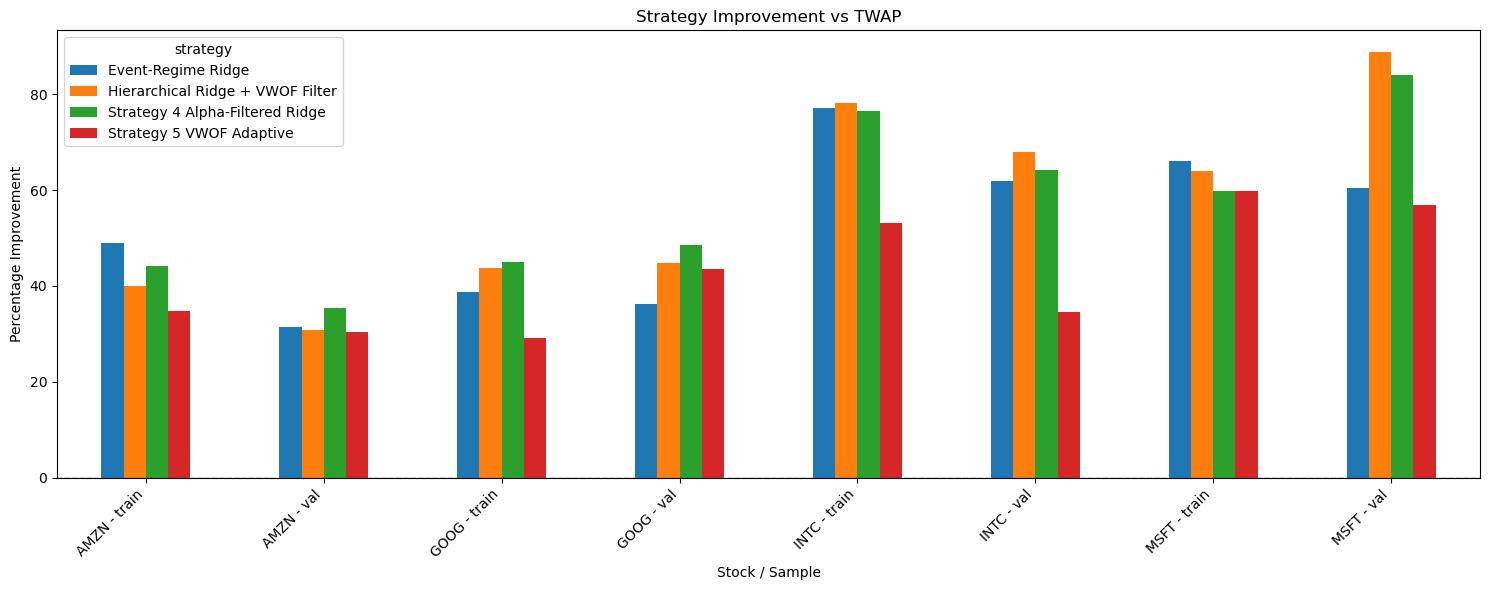

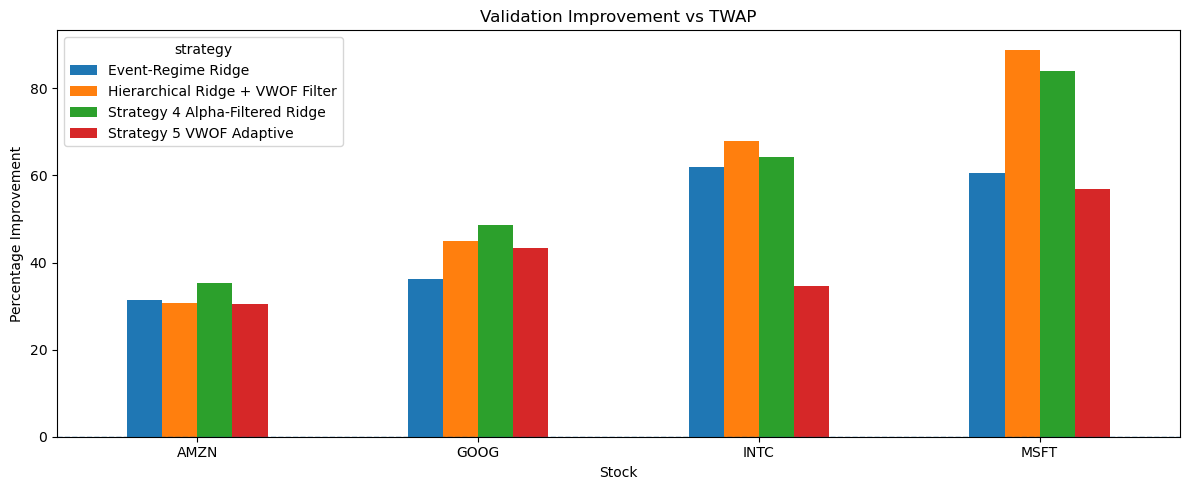

In [13]:
# ============================================================
# Plot: Strategy 4 vs Strategy 5 vs Regime Switching vs Hierarchical
# ============================================================

# ------------------------------------------------------------
# 1. 合并结果表
# ------------------------------------------------------------
eval_list = []

if "strategy4_eval" in globals():
    eval_list.append(strategy4_eval)

if "vwof_eval" in globals():
    eval_list.append(vwof_eval)

if "regime_eval" in globals():
    eval_list.append(regime_eval)

if "hierarchical_eval" in globals():
    eval_list.append(hierarchical_eval)

if len(eval_list) == 0:
    raise ValueError("没有找到可用于画图的 evaluation DataFrame。请先运行各策略的 evaluation cell。")

combined_eval_plot = pd.concat(eval_list, ignore_index=True)

display(combined_eval_plot.sort_values(["sample", "stock", "strategy"]))

# ------------------------------------------------------------
# 2. 全部 sample（train + val）画图
# ------------------------------------------------------------
plot_df_all = combined_eval_plot.copy()
plot_df_all["stock_sample"] = (
    plot_df_all["stock"].astype(str) + " - " + plot_df_all["sample"].astype(str)
)

pivot_all = plot_df_all.pivot_table(
    index="stock_sample",
    columns="strategy",
    values="PCT_IMPROVEMENT",
    aggfunc="first"
)

ax = pivot_all.plot(kind="bar", figsize=(15, 6))
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Strategy Improvement vs TWAP")
ax.set_ylabel("Percentage Improvement")
ax.set_xlabel("Stock / Sample")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. 只画 validation（更重要）
# ------------------------------------------------------------
plot_df_val = combined_eval_plot[
    combined_eval_plot["sample"] == "val"
].copy()

pivot_val = plot_df_val.pivot_table(
    index="stock",
    columns="strategy",
    values="PCT_IMPROVEMENT",
    aggfunc="first"
)

ax = pivot_val.plot(kind="bar", figsize=(12, 5))
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Validation Improvement vs TWAP")
ax.set_ylabel("Percentage Improvement")
ax.set_xlabel("Stock")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()